# Module 06c: GSEA Prerank Analysis

## Biological Question
Are there coordinated, directional pathway shifts between SnC and Non-SnC cells that may be missed by significance-based ORA?

## Rationale
GSEA uses all tested genes (ranked) rather than only significant DEGs, detecting subtle but coordinated pathway-level changes that ORA may miss.

## Method
- Rank all tested genes by: `-log10(pval) × sign(logFC)`
- Run GSEA prerank (GSEApy) against pathway databases

## Databases
Reactome_2022, KEGG_2021_Human, GO_Biological_Process_2023

## Cell Types
Microglia (primary), Astrocyte, OPC

In [1]:
# ============================================================
# MODULE 06c: GSEA PRERANK ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp
from pathlib import Path

# ------------------------------------------------------------
# Dataset Selection
# ------------------------------------------------------------
DATASET = 'psychad_aging'

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
BASE_DIR = Path('/fs/scratch/PAS2598/senescence_analysis')

# Input from Module 05
INPUT_DIR = BASE_DIR / 'results' / '05_deg' / DATASET

# Output directories
OUTPUT_DIR = BASE_DIR / 'data' / '06_pathway_enrichment' / DATASET / 'gsea_prerank'
RESULTS_DIR = BASE_DIR / 'results' / '06_pathway_enrichment' / DATASET / 'gsea_prerank'
FIGURES_DIR = BASE_DIR / 'figures' / '06_pathway_enrichment' / DATASET / 'gsea_prerank'

for d in [OUTPUT_DIR, RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Column Mapping (from Module 05 DEG output)
# ------------------------------------------------------------
COL_GENE = 'gene'
COL_LFC = 'avg_log2FC'
COL_PVAL = 'p_val'
COL_FDR = 'p_val_adj'

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
FDR_THRESHOLD = 0.05
RANKING_METHOD = 'signed_pval'  # -log10(pval) × sign(logFC)

# Focus on Microglia first
CELL_TYPE = 'Microglia'

# Start with one database
DATABASE = 'Reactome_2022'

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------
print("=" * 60)
print("MODULE 06c: GSEA PRERANK")
print("=" * 60)
print(f"\nDataset: {DATASET}")
print(f"Cell type: {CELL_TYPE}")
print(f"Database: {DATABASE}")
print(f"Ranking method: {RANKING_METHOD}")
print(f"\nPaths:")
print(f"  Input:   {INPUT_DIR}/")
print(f"  Output:  {OUTPUT_DIR}/")
print(f"  Results: {RESULTS_DIR}/")
print(f"  Figures: {FIGURES_DIR}/")

MODULE 06c: GSEA PRERANK

Dataset: psychad_aging
Cell type: Microglia
Database: Reactome_2022
Ranking method: signed_pval

Paths:
  Input:   /fs/scratch/PAS2598/senescence_analysis/results/05_deg/psychad_aging/
  Output:  /fs/scratch/PAS2598/senescence_analysis/data/06_pathway_enrichment/psychad_aging/gsea_prerank/
  Results: /fs/scratch/PAS2598/senescence_analysis/results/06_pathway_enrichment/psychad_aging/gsea_prerank/
  Figures: /fs/scratch/PAS2598/senescence_analysis/figures/06_pathway_enrichment/psychad_aging/gsea_prerank/


In [2]:
# ============================================================
# Load DEG Data
# ============================================================

# DEG file path
deg_file = INPUT_DIR / CELL_TYPE.lower() / f"{DATASET}_{CELL_TYPE.lower()}_SnCvsNonSnC_all.csv"

print(f"Loading: {deg_file.name}")

# Load data
df = pd.read_csv(deg_file)

print(f"\n✓ Loaded {len(df):,} genes")
print(f"\nColumns: {list(df.columns)}")
print(f"\nHead:")
print(df.head())

Loading: psychad_aging_microglia_SnCvsNonSnC_all.csv

✓ Loaded 33,557 genes

Columns: ['p_val', 'avg_log2FC', 'pct.1', 'pct.2', 'p_val_adj', 'gene', 'significant', 'direction']

Head:
          p_val  avg_log2FC  pct.1  pct.2     p_val_adj      gene significant  \
0  2.280610e-16   -0.702987  0.738  0.960  7.957048e-12  SLC22A17        True   
1  2.491085e-15   -0.476037  0.913  0.992  8.691395e-11       CLU       False   
2  6.940472e-15   -0.448280  0.893  0.984  2.421531e-10     GPM6B       False   
3  2.258322e-14    1.585771  0.864  0.952  7.879286e-10    ADARB2        True   
4  2.695788e-13   -0.529541  0.845  0.968  9.405604e-09     PEBP1        True   

  direction  
0      Down  
1        NS  
2        NS  
3        Up  
4      Down  


In [3]:
# ============================================================
# Create Ranking Metric
# ============================================================

def create_ranking(df: pd.DataFrame, method: str = 'signed_pval') -> pd.Series:
    """
    Create gene ranking for GSEA prerank.
    
    Methods:
    - 'signed_pval': -log10(pval) × sign(logFC) — rewards significance + direction
    - 'logFC': Simple log fold change
    """
    if method == 'signed_pval':
        # Clip p-values to avoid inf
        pval_clipped = df[COL_PVAL].clip(lower=1e-300)
        score = -np.log10(pval_clipped) * np.sign(df[COL_LFC])
        ranking = pd.Series(score.values, index=df[COL_GENE])
    elif method == 'logFC':
        ranking = df.set_index(COL_GENE)[COL_LFC]
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Remove NaN/inf and sort
    ranking = ranking.replace([np.inf, -np.inf], np.nan).dropna()
    ranking = ranking.sort_values(ascending=False)
    
    return ranking

# Create ranking
ranking = create_ranking(df, method=RANKING_METHOD)

# Display
N_DISPLAY = 10

print(f"Ranking method: {RANKING_METHOD}")
print(f"Genes ranked: {len(ranking):,}")
print(f"\nTop {N_DISPLAY} (upregulated in SnC):")
print(ranking.head(N_DISPLAY))
print(f"\nBottom {N_DISPLAY} (downregulated in SnC):")
print(ranking.tail(N_DISPLAY))

Ranking method: signed_pval
Genes ranked: 33,454

Top 10 (upregulated in SnC):
gene
ADARB2             13.646214
CENPU               9.972150
LINC02336           8.119908
ENSG00000277151     7.888219
ZNF488              7.577134
LINC01018           7.543606
LINC02527           7.458711
DDIAS               7.381126
ENSG00000256966     7.279241
GTF2IP14            7.246064
dtype: float64

Bottom 10 (downregulated in SnC):
gene
CPE         -10.607689
MT3         -10.694372
PCDH9-AS2   -11.186898
CKB         -11.285145
TF          -12.195279
GDI1        -12.504549
PEBP1       -12.569314
GPM6B       -14.158611
CLU         -14.603611
SLC22A17    -15.641949
dtype: float64


In [4]:
# ============================================================
# Run GSEA Prerank
# ============================================================

print(f"Running GSEA prerank: {DATABASE}")
print(f"Genes: {len(ranking):,}")

# Output directory for this run
outdir = OUTPUT_DIR / CELL_TYPE.lower() / DATABASE

pre_res = gp.prerank(
    rnk=ranking,
    gene_sets=DATABASE,
    outdir=str(outdir),
    min_size=15,
    max_size=500,
    permutation_num=1000,
    threads=4,
    seed=42,
    verbose=True
)

print(f"\n✓ Complete")
print(f"Output: {outdir}")

2026-01-22 17:09:18,585 [WARNING] Duplicated values found in preranked stats: 0.41% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-01-22 17:09:18,585 [INFO] Parsing data files for GSEA.............................
2026-01-22 17:09:18,625 [INFO] Enrichr library gene sets already downloaded in: /users/PAS2598/ggaitos/.cache/gseapy, use local file
2026-01-22 17:09:18,666 [INFO] 0683 gene_sets have been filtered out when max_size=500 and min_size=15
2026-01-22 17:09:18,666 [INFO] 1135 gene_sets used for further statistical testing.....
2026-01-22 17:09:18,667 [INFO] Start to run GSEA...Might take a while..................


Running GSEA prerank: Reactome_2022
Genes: 33,454


2026-01-22 17:10:19,021 [INFO] Congratulations. GSEApy runs successfully................




✓ Complete
Output: /fs/scratch/PAS2598/senescence_analysis/data/06_pathway_enrichment/psychad_aging/gsea_prerank/microglia/Reactome_2022


In [5]:
# ============================================================
# Examine Results
# ============================================================

# Results dataframe
res = pre_res.res2d

print(f"Results: {len(res)} pathways tested")
print(f"\nColumns: {list(res.columns)}")

# Significant pathways
n_sig = (res['FDR q-val'] < FDR_THRESHOLD).sum()
n_up = ((res['FDR q-val'] < FDR_THRESHOLD) & (res['NES'] > 0)).sum()
n_down = ((res['FDR q-val'] < FDR_THRESHOLD) & (res['NES'] < 0)).sum()

print(f"\nSignificant (FDR < {FDR_THRESHOLD}): {n_sig}")
print(f"  Enriched in SnC (NES > 0): {n_up}")
print(f"  Enriched in Non-SnC (NES < 0): {n_down}")

print(f"\nTop results:")
print(res.head(10))

Results: 1135 pathways tested

Columns: ['Name', 'Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val', 'FWER p-val', 'Tag %', 'Gene %', 'Lead_genes']

Significant (FDR < 0.05): 52
  Enriched in SnC (NES > 0): 8
  Enriched in Non-SnC (NES < 0): 44

Top results:
      Name                                               Term        ES  \
0  prerank  GABA Synthesis, Release, Reuptake And Degradat... -0.754103   
1  prerank      Polo-like Kinase Mediated Events R-HSA-156711  0.852906   
2  prerank                  Selective Autophagy R-HSA-9663891 -0.574875   
3  prerank  Negative Regulation Of MAPK Pathway R-HSA-5675221 -0.622082   
4  prerank         Chaperone Mediated Autophagy R-HSA-9613829 -0.705134   
5  prerank              Cholesterol Biosynthesis R-HSA-191273 -0.669535   
6  prerank  Respiratory Electron Transport, ATP Synthesis ... -0.513941   
7  prerank  Serotonin Neurotransmitter Release Cycle R-HSA... -0.723709   
8  prerank  Dopamine Neurotransmitter Release Cycle R-HSA-... -0.674879

In [6]:
# ============================================================
# Top Pathways by Direction
# ============================================================

# Filter significant
sig = res[res['FDR q-val'] < FDR_THRESHOLD].copy()

# Split by direction
sig_up = sig[sig['NES'] > 0].sort_values('NES', ascending=False)
sig_down = sig[sig['NES'] < 0].sort_values('NES', ascending=True)

# Display columns
display_cols = ['Term', 'NES', 'FDR q-val', 'Lead_genes']

print(f"Enriched in SnC (NES > 0): {len(sig_up)} pathways")
print("=" * 60)
print(sig_up[display_cols].head(10).to_string(index=False))

print(f"\n\nEnriched in Non-SnC (NES < 0): {len(sig_down)} pathways")
print("=" * 60)
print(sig_down[display_cols].head(10).to_string(index=False))

Enriched in SnC (NES > 0): 8 pathways
                                                                                          Term       NES FDR q-val                                                                                                                                                                    Lead_genes
                                                 Polo-like Kinase Mediated Events R-HSA-156711  2.080225  0.000459                                                                                                                       CCNB2;MYBL2;CDC25A;FOXM1;WEE1;CCNB1;CENPF;CDC25C;PKMYT1
                                                 Resolution Of D-Loop Structures R-HSA-5693537  1.973214  0.002981                                                                                        BARD1;RAD51AP1;EXO1;EME1;BRIP1;XRCC2;GEN1;RAD50;RAD51B;RAD51;RMI2;DNA2;BRCA2;BLM;RTEL1
            Resolution Of D-loop Structures Thru Holliday Junction Intermediates R-HSA-5693568 

In [7]:
# ============================================================
# Save Results
# ============================================================

# Add metadata
res_out = res.copy()
res_out['Cell_Type'] = CELL_TYPE
res_out['Database'] = DATABASE
res_out['Dataset'] = DATASET

# Save full results
outfile = RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_{DATABASE}_gsea_prerank.csv"
res_out.to_csv(outfile, index=False)

print(f"✓ Saved: {outfile.name}")
print(f"  Total pathways: {len(res_out)}")
print(f"  Significant (FDR < {FDR_THRESHOLD}): {n_sig}")

✓ Saved: psychad_aging_microglia_Reactome_2022_gsea_prerank.csv
  Total pathways: 1135
  Significant (FDR < 0.05): 52


/tmp/ipykernel_1536739/2722690725.py:34: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


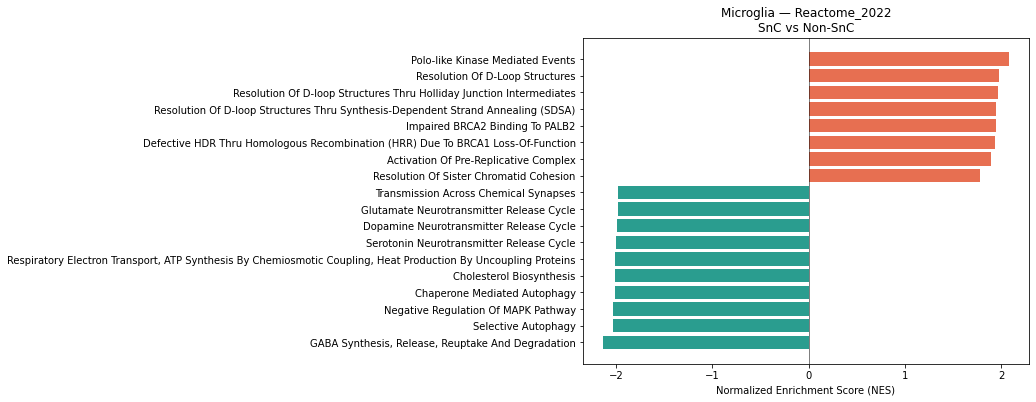


✓ Saved figure


In [8]:
# ============================================================
# Visualize: NES Bar Plot
# ============================================================

# Visualization
N_TOP = 10
N_DISPLAY = 10

# Colors
COLORS = {
    'up': '#E76F51',    # Burnt sienna
    'down': '#2A9D8F',  # Teal
}

top_up = sig_up.head(N_TOP).copy()
top_down = sig_down.head(N_TOP).copy()

# Combine and sort by NES
plot_df = pd.concat([top_up, top_down]).sort_values('NES', ascending=True)

# Clean pathway names (remove R-HSA-* suffix)
plot_df['Term_clean'] = plot_df['Term'].str.replace(r'\s*R-HSA-\d+$', '', regex=True)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

colors = [COLORS['up'] if x > 0 else COLORS['down'] for x in plot_df['NES']]

ax.barh(plot_df['Term_clean'], plot_df['NES'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Normalized Enrichment Score (NES)')
ax.set_title(f'{CELL_TYPE} — {DATABASE}\nSnC vs Non-SnC')

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_{DATABASE}_nes_barplot.png")
plt.show()

print(f"\n✓ Saved figure")


In [9]:
# ============================================================
# GSEA Enrichment Plot (Classic)
# ============================================================

# Check what's in the output directory
outdir = OUTPUT_DIR / CELL_TYPE.lower() / DATABASE
print(f"Output directory: {outdir}")
print(f"\nFiles generated:")
for f in sorted(outdir.glob('*'))[:20]:
    print(f"  {f.name}")

Output directory: /fs/scratch/PAS2598/senescence_analysis/data/06_pathway_enrichment/psychad_aging/gsea_prerank/microglia/Reactome_2022

Files generated:
  gene_sets.gmt
  gseapy.gene_set.prerank.report.csv
  prerank
  prerank_data.rnk


Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


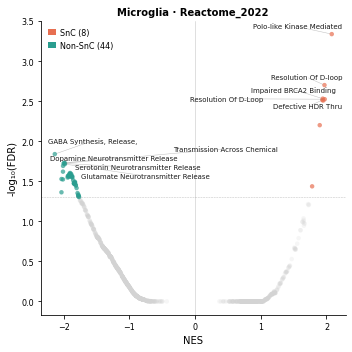

✓ Saved volcano plot


In [10]:
# ============================================================
# Visualize: Volcano Plot (NES vs -log10 FDR)
# ============================================================

from adjustText import adjust_text

# Prepare data
plot_df = res.copy()

# Ensure numeric dtypes
plot_df['NES'] = pd.to_numeric(plot_df['NES'], errors='coerce')
plot_df['FDR q-val'] = pd.to_numeric(plot_df['FDR q-val'], errors='coerce')

# Calculate -log10(FDR)
plot_df['neg_log10_fdr'] = -np.log10(plot_df['FDR q-val'].clip(lower=1e-10))

# Classify pathways
def classify_pathway(row):
    if row['FDR q-val'] >= FDR_THRESHOLD:
        return 'NS'
    elif row['NES'] > 0:
        return 'Up'
    else:
        return 'Down'

plot_df['Category'] = plot_df.apply(classify_pathway, axis=1)

# Colors
color_map = {
    'Up': COLORS['up'],
    'Down': COLORS['down'],
    'NS': '#D3D3D3'
}

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

for cat in ['NS', 'Down', 'Up']:
    subset = plot_df[plot_df['Category'] == cat]
    ax.scatter(
        subset['NES'],
        subset['neg_log10_fdr'],
        c=color_map[cat],
        alpha=0.7 if cat != 'NS' else 0.2,
        s=20,
        edgecolors='none'
    )

# Reference lines
fdr_line = -np.log10(FDR_THRESHOLD)
ax.axhline(fdr_line, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

# Label top pathways (non-overlapping)
n_label = 5
top_up = plot_df[plot_df['Category'] == 'Up'].nlargest(n_label, 'neg_log10_fdr')
top_down = plot_df[plot_df['Category'] == 'Down'].nlargest(n_label, 'neg_log10_fdr')
to_label = pd.concat([top_up, top_down])

texts = []
for _, row in to_label.iterrows():
    # Clean pathway name (first 2-3 words)
    words = row['Term'].split()[0:3]
    label = ' '.join(words)
    
    texts.append(ax.text(
        row['NES'], 
        row['neg_log10_fdr'], 
        label,
        fontsize=7,
        alpha=0.9
    ))

# Adjust text positions to avoid overlap
adjust_text(
    texts, 
    ax=ax,
    arrowprops=dict(arrowstyle='-', color='gray', lw=0.5, alpha=0.5),
    expand_points=(1.5, 1.5),
    force_points=(0.5, 0.5)
)

# Styling
ax.set_xlabel('NES', fontsize=10)
ax.set_ylabel('-log₁₀(FDR)', fontsize=10)
ax.set_title(f'{CELL_TYPE} · {DATABASE}', fontsize=10, fontweight='bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=8)

# Legend (top left)
from matplotlib.patches import Patch
n_up = (plot_df['Category'] == 'Up').sum()
n_down = (plot_df['Category'] == 'Down').sum()

legend_elements = [
    Patch(facecolor=COLORS['up'], label=f'SnC ({n_up})'),
    Patch(facecolor=COLORS['down'], label=f'Non-SnC ({n_down})')
]
ax.legend(
    handles=legend_elements, 
    loc='upper left', 
    frameon=False, 
    fontsize=8,
    handlelength=1,
    handletextpad=0.5
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_{DATABASE}_volcano.png", dpi=300)
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_{DATABASE}_volcano.pdf")
plt.show()

print(f"✓ Saved volcano plot")

In [11]:
# ============================================================
# Scale to All Databases
# ============================================================

DATABASES = ['Reactome_2022', 'KEGG_2021_Human', 'GO_Biological_Process_2023']

# Store results
all_results = {}

for db in DATABASES:
    print(f"\n{'='*60}")
    print(f"Running: {db}")
    print('='*60)
    
    # Output directory
    outdir = OUTPUT_DIR / CELL_TYPE.lower() / db
    
    # Run GSEA prerank
    pre_res = gp.prerank(
        rnk=ranking,
        gene_sets=db,
        outdir=str(outdir),
        min_size=15,
        max_size=500,
        permutation_num=1000,
        threads=4,
        seed=42,
        verbose=False
    )
    
    # Get results
    res = pre_res.res2d.copy()
    res['NES'] = pd.to_numeric(res['NES'], errors='coerce')
    res['FDR q-val'] = pd.to_numeric(res['FDR q-val'], errors='coerce')
    
    # Add metadata
    res['Database'] = db
    res['Cell_Type'] = CELL_TYPE
    res['Dataset'] = DATASET
    
    all_results[db] = res
    
    # Summary
    n_sig = (res['FDR q-val'] < FDR_THRESHOLD).sum()
    n_up = ((res['FDR q-val'] < FDR_THRESHOLD) & (res['NES'] > 0)).sum()
    n_down = ((res['FDR q-val'] < FDR_THRESHOLD) & (res['NES'] < 0)).sum()
    
    print(f"✓ Tested: {len(res)} pathways")
    print(f"  Significant: {n_sig} (SnC: {n_up}, Non-SnC: {n_down})")

# Combine all results
combined = pd.concat(all_results.values(), ignore_index=True)

# Save combined
outfile = RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_gsea_prerank_all.csv"
combined.to_csv(outfile, index=False)

print(f"\n{'='*60}")
print(f"✓ Saved combined results: {outfile.name}")
print(f"  Total pathways: {len(combined)}")

2026-01-22 17:10:20,206 [WARNING] Duplicated values found in preranked stats: 0.41% of genes
The order of those genes will be arbitrary, which may produce unexpected results.



Running: Reactome_2022


2026-01-22 17:11:23,534 [WARNING] Duplicated values found in preranked stats: 0.41% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


✓ Tested: 1135 pathways
  Significant: 52 (SnC: 8, Non-SnC: 44)

Running: KEGG_2021_Human


2026-01-22 17:11:54,621 [WARNING] Duplicated values found in preranked stats: 0.41% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


✓ Tested: 305 pathways
  Significant: 5 (SnC: 0, Non-SnC: 5)

Running: GO_Biological_Process_2023
✓ Tested: 2527 pathways
  Significant: 63 (SnC: 1, Non-SnC: 62)

✓ Saved combined results: psychad_aging_microglia_gsea_prerank_all.csv
  Total pathways: 3967


In [12]:
# ============================================================
# Summary Across Databases
# ============================================================

print(f"{'='*60}")
print(f"GSEA PRERANK SUMMARY: {CELL_TYPE}")
print(f"{'='*60}")

summary_rows = []
for db, res in all_results.items():
    n_tested = len(res)
    n_sig = (res['FDR q-val'] < FDR_THRESHOLD).sum()
    n_up = ((res['FDR q-val'] < FDR_THRESHOLD) & (res['NES'] > 0)).sum()
    n_down = ((res['FDR q-val'] < FDR_THRESHOLD) & (res['NES'] < 0)).sum()
    
    summary_rows.append({
        'Database': db,
        'Tested': n_tested,
        'Significant': n_sig,
        'SnC': n_up,
        'Non-SnC': n_down
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# Save summary
summary_file = RESULTS_DIR / f"{DATASET}_{CELL_TYPE.lower()}_gsea_summary.csv"
summary_df.to_csv(summary_file, index=False)
print(f"\n✓ Saved: {summary_file.name}")

GSEA PRERANK SUMMARY: Microglia
                  Database  Tested  Significant  SnC  Non-SnC
             Reactome_2022    1135           52    8       44
           KEGG_2021_Human     305            5    0        5
GO_Biological_Process_2023    2527           63    1       62

✓ Saved: psychad_aging_microglia_gsea_summary.csv


In [13]:
# ============================================================
# Top Pathways Per Database
# ============================================================

N_SHOW = 10

for db, res in all_results.items():
    sig = res[res['FDR q-val'] < FDR_THRESHOLD].copy()
    
    sig_up = sig[sig['NES'] > 0].sort_values('NES', ascending=False)
    sig_down = sig[sig['NES'] < 0].sort_values('NES', ascending=True)
    
    print(f"\n{'='*60}")
    print(f"{db}")
    print(f"{'='*60}")
    
    if len(sig_up) > 0:
        print(f"\nEnriched in SnC ({len(sig_up)}):")
        for _, row in sig_up.head(N_SHOW).iterrows():
            print(f"  {row['NES']:>6.2f}  {row['Term'][:60]}")
    else:
        print(f"\nEnriched in SnC: None")
    
    if len(sig_down) > 0:
        print(f"\nEnriched in Non-SnC ({len(sig_down)}):")
        for _, row in sig_down.head(N_SHOW).iterrows():
            print(f"  {row['NES']:>6.2f}  {row['Term'][:60]}")
    else:
        print(f"\nEnriched in Non-SnC: None")


Reactome_2022

Enriched in SnC (8):
    2.08  Polo-like Kinase Mediated Events R-HSA-156711
    1.97  Resolution Of D-Loop Structures R-HSA-5693537
    1.97  Resolution Of D-loop Structures Thru Holliday Junction Inter
    1.95  Resolution Of D-loop Structures Thru Synthesis-Dependent Str
    1.94  Impaired BRCA2 Binding To PALB2 R-HSA-9709603
    1.94  Defective HDR Thru Homologous Recombination (HRR) Due To BRC
    1.90  Activation Of Pre-Replicative Complex R-HSA-68962
    1.78  Resolution Of Sister Chromatid Cohesion R-HSA-2500257

Enriched in Non-SnC (44):
   -2.14  GABA Synthesis, Release, Reuptake And Degradation R-HSA-8885
   -2.04  Selective Autophagy R-HSA-9663891
   -2.04  Negative Regulation Of MAPK Pathway R-HSA-5675221
   -2.01  Chaperone Mediated Autophagy R-HSA-9613829
   -2.01  Cholesterol Biosynthesis R-HSA-191273
   -2.01  Respiratory Electron Transport, ATP Synthesis By Chemiosmoti
   -2.00  Serotonin Neurotransmitter Release Cycle R-HSA-181429
   -1.99  Dopamine N

1 [-0.93757665  0.76871166]
10 [0.17318085 0.5657652 ]


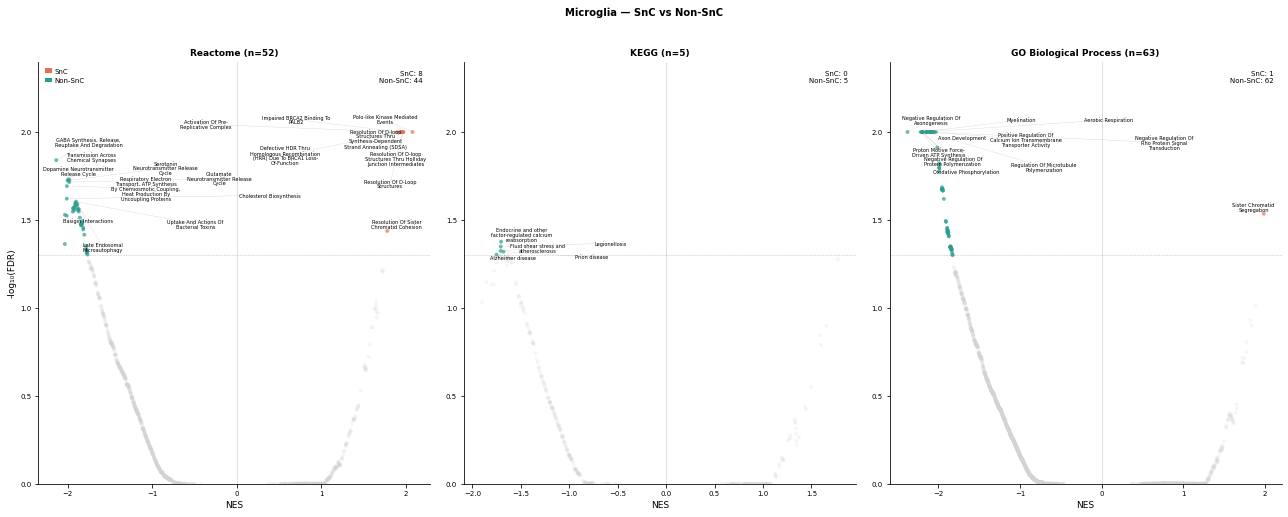

✓ Saved volcano panel


In [14]:
# ============================================================
# Volcano Plots: All Databases (Panel) - Wrapped Labels
# ============================================================

from adjustText import adjust_text
from matplotlib.patches import Patch
import textwrap

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Parameters
CLIP_LOWER = 1e-2
N_LABEL = 10
WRAP_WIDTH = 25  # Characters per line

# Calculate consistent y-axis limit
y_max = 0
for db, res in all_results.items():
    fdr_vals = pd.to_numeric(res['FDR q-val'], errors='coerce').clip(lower=CLIP_LOWER)
    y_max = max(y_max, (-np.log10(fdr_vals)).max())
y_max = y_max * 1.2

for idx, (db, res) in enumerate(all_results.items()):
    ax = axes[idx]
    
    # Prepare data
    plot_df = res.copy()
    plot_df['neg_log10_fdr'] = -np.log10(plot_df['FDR q-val'].clip(lower=CLIP_LOWER))
    
    # Classify
    def classify_pathway(row):
        if row['FDR q-val'] >= FDR_THRESHOLD:
            return 'NS'
        elif row['NES'] > 0:
            return 'Up'
        else:
            return 'Down'
    
    plot_df['Category'] = plot_df.apply(classify_pathway, axis=1)
    
    # Plot
    for cat in ['NS', 'Down', 'Up']:
        subset = plot_df[plot_df['Category'] == cat]
        ax.scatter(
            subset['NES'],
            subset['neg_log10_fdr'],
            c={'Up': COLORS['up'], 'Down': COLORS['down'], 'NS': '#D3D3D3'}[cat],
            alpha=0.7 if cat != 'NS' else 0.2,
            s=15,
            edgecolors='none'
        )
    
    # Reference lines
    fdr_line = -np.log10(FDR_THRESHOLD)
    ax.axhline(fdr_line, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
    
    # Top N labels per direction
    top_up = plot_df[plot_df['Category'] == 'Up'].nlargest(N_LABEL, 'neg_log10_fdr')
    top_down = plot_df[plot_df['Category'] == 'Down'].nlargest(N_LABEL, 'neg_log10_fdr')
    to_label = pd.concat([top_up, top_down])
    
    texts = []
    for _, row in to_label.iterrows():
        # Clean label
        label = row['Term']
        label = label.split(' (GO:')[0]
        label = label.split(' R-HSA-')[0]
        
        # Wrap text
        label = '\n'.join(textwrap.wrap(label, width=WRAP_WIDTH))
        
        texts.append(ax.text(
            row['NES'], 
            row['neg_log10_fdr'], 
            label, 
            fontsize=5,
            linespacing=0.9
        ))
    
    if texts:
        adjust_text(
            texts, 
            ax=ax,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.3, alpha=0.4),
            expand_points=(3, 3),
            expand_text=(1.5, 1.5),
            force_points=(2, 2),
            force_text=(1, 1),
            time_lim=10
        )
    
    # Consistent axis limits
    ax.set_ylim(0, y_max)
    
    # Styling
    ax.set_xlabel('NES', fontsize=9)
    if idx == 0:
        ax.set_ylabel('-log₁₀(FDR)', fontsize=9)
    
    db_clean = db.replace('_', ' ').replace('2022', '').replace('2021 Human', '').replace('2023', '').strip()
    n_up = (plot_df['Category'] == 'Up').sum()
    n_down = (plot_df['Category'] == 'Down').sum()
    ax.set_title(f'{db_clean} (n={n_up + n_down})', fontsize=9, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(labelsize=7)
    
    # Counts (top right)
    ax.text(0.98, 0.98, f'SnC: {n_up}\nNon-SnC: {n_down}', 
            transform=ax.transAxes, fontsize=7, va='top', ha='right')

# Legend (first panel)
legend_elements = [
    Patch(facecolor=COLORS['up'], label='SnC'),
    Patch(facecolor=COLORS['down'], label='Non-SnC')
]
axes[0].legend(
    handles=legend_elements, 
    loc='upper left',
    frameon=False, 
    fontsize=7,
    handlelength=1,
    handletextpad=0.4
)

plt.suptitle(f'{CELL_TYPE} — SnC vs Non-SnC', fontsize=10, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_gsea_volcano_panel.png", dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / f"{DATASET}_{CELL_TYPE.lower()}_gsea_volcano_panel.pdf", bbox_inches='tight')
plt.show()

print(f"✓ Saved volcano panel")

In [15]:
# ============================================================
# Sankey Diagram: Gene → Pathway → General Category → Cell Type
# FLEXIBLE VERSION - Auto-categorizes based on keywords
# ENLARGED FONTS
# ============================================================

print("=" * 60)
print("CREATING SANKEY DIAGRAM")
print("=" * 60)

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("✓ Plotly loaded")
except ImportError:
    PLOTLY_AVAILABLE = False
    print("✗ Plotly not available")

try:
    import kaleido
    KALEIDO_AVAILABLE = True
    print("✓ Kaleido loaded")
except ImportError:
    KALEIDO_AVAILABLE = False
    print("✗ Kaleido not available")

if PLOTLY_AVAILABLE:
    
    # ------------------------------------------------------------
    # Parameters - CHANGE DATABASE HERE
    # ------------------------------------------------------------
    # DATABASE = 'KEGG_2021_Human'
    # DATABASE = 'GO_Biological_Process_2023'
    DATABASE = 'Reactome_2022'
    
    TOP_N_PATHWAYS = 10
    MAX_GENES_PER_PATHWAY = 5
    MAX_PATHWAY_LEN = 45
    
    DB_DISPLAY = DATABASE.replace('_', ' ').replace('2022', '').replace('2021 Human', '').replace('2023', '').strip()
    
    # ------------------------------------------------------------
    # Keyword-based category mapping (order matters - first match wins)
    # ------------------------------------------------------------
    CATEGORY_KEYWORDS = {
        'Cell Cycle': [
            'cell cycle', 'mitotic', 'mitosis', 'meiosis', 'chromosome segregation',
            'sister chromatid', 'spindle', 'centrosome', 'kinetochore', 'cytokinesis',
            'g1/s', 'g2/m', 's phase', 'cdk', 'cyclin', 'replicat', 'pre-replicat'
        ],
        'DNA Damage Response': [
            'dna repair', 'dna damage', 'double-strand break', 'homologous recombination',
            'base excision', 'nucleotide excision', 'mismatch repair', 'brca', 'atm', 'atr',
            'p53', 'checkpoint', 'd-loop', 'holliday junction'
        ],
        'Apoptosis & Senescence': [
            'apoptosis', 'apoptotic', 'programmed cell death', 'senescence', 'autophagy',
            'necroptosis', 'ferroptosis', 'pyroptosis', 'caspase', 'bcl-2', 'death receptor'
        ],
        'Energy Metabolism': [
            'oxidative phosphorylation', 'electron transport', 'atp synthesis', 'mitochondri',
            'respiratory chain', 'krebs', 'tca cycle', 'citric acid', 'glycolysis', 
            'gluconeogenesis', 'aerobic respiration', 'proton motive'
        ],
        'Lipid Metabolism': [
            'lipid', 'cholesterol', 'fatty acid', 'sphingolipid', 'phospholipid',
            'steroid', 'triglyceride', 'lipoprotein', 'adipogenesis'
        ],
        'Neurotransmitter & Synaptic': [
            'neurotransmitter', 'synaptic', 'synapse', 'gaba', 'glutamate', 'dopamine',
            'serotonin', 'acetylcholine', 'norepinephrine', 'receptor potential',
            'action potential', 'ion channel', 'postsynaptic', 'presynaptic'
        ],
        'Neurodegeneration': [
            'alzheimer', 'parkinson', 'huntington', 'prion', 'amyloid', 'tau protein',
            'neurodegenerat', 'dementia', 'als', 'amyotrophic'
        ],
        'Axon & Myelination': [
            'axon', 'myelination', 'myelin', 'oligodendrocyte', 'schwann', 'nerve growth',
            'neurite', 'dendrit', 'axonogenesis', 'neurogenesis'
        ],
        'Cytoskeleton': [
            'cytoskelet', 'actin', 'microtubule', 'tubulin', 'intermediate filament',
            'polymerization', 'depolymerization', 'motor protein', 'kinesin', 'dynein'
        ],
        'Immune & Inflammation': [
            'immune', 'inflammat', 'cytokine', 'interleukin', 'interferon', 'nf-kb',
            'toll-like', 'complement', 'antigen', 'mhc', 't cell', 'b cell', 'macrophage',
            'neutrophil', 'phagocyt', 'chemokine', 'legionell'
        ],
        'Signal Transduction': [
            'signal', 'mapk', 'erk', 'jnk', 'p38', 'pi3k', 'akt', 'mtor', 'wnt',
            'notch', 'hedgehog', 'tgf-beta', 'bmp', 'jak-stat', 'rho', 'ras',
            'g protein', 'kinase', 'phosphatase', 'calcium', 'camp', 'second messenger'
        ],
        'Vascular & Cardiovascular': [
            'vascular', 'angiogenesis', 'blood vessel', 'endotheli', 'atherosclerosis',
            'cardiac', 'heart', 'artery', 'vein', 'shear stress', 'blood pressure'
        ],
        'Transcription & Epigenetics': [
            'transcription', 'chromatin', 'histone', 'methylation', 'acetylation',
            'epigenetic', 'gene expression', 'promoter', 'enhancer', 'silencing'
        ],
        'Protein Homeostasis': [
            'proteasome', 'ubiquitin', 'protein folding', 'chaperone', 'heat shock',
            'unfolded protein', 'er stress', 'protein degradation', 'autophagy'
        ],
    }
    
    # Direction colors
    DIRECTION_LINK_COLORS = {
        'SnC': 'rgba(231, 111, 81, 0.5)',
        'Non-SnC': 'rgba(42, 157, 143, 0.5)',
    }
    
    # Category colors
    CATEGORY_COLORS = {
        'Cell Cycle': 'rgba(230, 57, 70, 0.85)',
        'DNA Damage Response': 'rgba(247, 127, 0, 0.85)',
        'Apoptosis & Senescence': 'rgba(180, 60, 60, 0.85)',
        'Energy Metabolism': 'rgba(82, 183, 136, 0.85)',
        'Lipid Metabolism': 'rgba(233, 196, 106, 0.85)',
        'Neurotransmitter & Synaptic': 'rgba(42, 157, 143, 0.85)',
        'Neurodegeneration': 'rgba(168, 50, 50, 0.85)',
        'Axon & Myelination': 'rgba(100, 140, 180, 0.85)',
        'Cytoskeleton': 'rgba(52, 78, 65, 0.85)',
        'Immune & Inflammation': 'rgba(218, 165, 32, 0.85)',
        'Signal Transduction': 'rgba(155, 93, 229, 0.85)',
        'Vascular & Cardiovascular': 'rgba(70, 130, 180, 0.85)',
        'Transcription & Epigenetics': 'rgba(147, 112, 219, 0.85)',
        'Protein Homeostasis': 'rgba(60, 179, 113, 0.85)',
        'Other': 'rgba(150, 150, 150, 0.85)',
    }
    
    CATEGORY_LINK_COLORS = {cat: col.replace('0.85', '0.5') for cat, col in CATEGORY_COLORS.items()}
    
    # Cell type colors
    CELLTYPE_COLORS = {
        'Microglia': 'rgba(244, 162, 97, 0.9)',
        'Astrocyte': 'rgba(38, 70, 83, 0.9)',
        'OPC': 'rgba(138, 177, 125, 0.9)'
    }
    CELLTYPE_LINK_COLORS = {
        'Microglia': 'rgba(244, 162, 97, 0.5)',
        'Astrocyte': 'rgba(38, 70, 83, 0.5)',
        'OPC': 'rgba(138, 177, 125, 0.5)'
    }
    
    # ------------------------------------------------------------
    # Auto-categorization function
    # ------------------------------------------------------------
    def get_category(pathway_name):
        """Assign category based on keyword matching."""
        pw_lower = pathway_name.lower().replace('<br>', ' ')
        
        for category, keywords in CATEGORY_KEYWORDS.items():
            for kw in keywords:
                if kw in pw_lower:
                    return category
        return 'Other'
    
    # ------------------------------------------------------------
    # Prepare data
    # ------------------------------------------------------------
    res = all_results[DATABASE].copy()
    res['NES'] = pd.to_numeric(res['NES'], errors='coerce')
    res['FDR q-val'] = pd.to_numeric(res['FDR q-val'], errors='coerce')
    
    sig = res[res['FDR q-val'] < FDR_THRESHOLD].copy()
    sig['Direction'] = sig['NES'].apply(lambda x: 'SnC' if x > 0 else 'Non-SnC')
    
    def clean_pathway(name):
        import re
        name = re.sub(r'\s*R-HSA-\d+$', '', name)
        name = re.sub(r'\s*\(GO:\d+\)$', '', name)
        return name
    
    sig['Pathway'] = sig['Term'].apply(clean_pathway)
    
    def wrap_text(text, max_len=MAX_PATHWAY_LEN):
        if len(text) <= max_len:
            return text
        words = text.split()
        lines = []
        current_line = ""
        for word in words:
            if len(current_line) + len(word) + 1 <= max_len:
                current_line += (" " if current_line else "") + word
            else:
                if current_line:
                    lines.append(current_line)
                current_line = word
        if current_line:
            lines.append(current_line)
        return "<br>".join(lines[:2])
    
    sig_up = sig[sig['NES'] > 0].nlargest(TOP_N_PATHWAYS, 'NES')
    sig_down = sig[sig['NES'] < 0].nsmallest(TOP_N_PATHWAYS, 'NES')
    plot_df = pd.concat([sig_up, sig_down])
    
    print(f"\nDatabase: {DATABASE}")
    print(f"Pathways included: {len(plot_df)}")
    print(f"  SnC: {len(sig_up)}, Non-SnC: {len(sig_down)}")
    
    # Check if we have any data to plot
    if len(plot_df) == 0:
        print("\n⚠ No significant pathways to plot!")
    else:
        # ------------------------------------------------------------
        # Build data structures
        # ------------------------------------------------------------
        snc_genes = []
        nonsnc_genes = []
        snc_pathways = []
        nonsnc_pathways = []
        gene_pathway_links = []
        pathway_direction = {}
        gene_direction = {}
        pathway_to_cat = {}
        
        # Process SnC pathways first
        for _, row in sig_up.iterrows():
            pathway = row['Pathway']
            pathway_wrapped = wrap_text(pathway)
            direction = 'SnC'
            
            if pd.isna(row['Lead_genes']) or row['Lead_genes'] == '':
                continue
            
            genes = [g.strip() for g in row['Lead_genes'].split(';') if g.strip()]
            genes = genes[:MAX_GENES_PER_PATHWAY]
            
            if pathway_wrapped not in snc_pathways:
                snc_pathways.append(pathway_wrapped)
                pathway_direction[pathway_wrapped] = direction
                pathway_to_cat[pathway_wrapped] = get_category(pathway)
            
            for gene in genes:
                if gene not in snc_genes and gene not in nonsnc_genes:
                    snc_genes.append(gene)
                    gene_direction[gene] = direction
                gene_pathway_links.append({
                    'gene': gene,
                    'pathway': pathway_wrapped,
                    'direction': direction,
                    'category': pathway_to_cat[pathway_wrapped]
                })
        
        # Then Non-SnC pathways
        for _, row in sig_down.iterrows():
            pathway = row['Pathway']
            pathway_wrapped = wrap_text(pathway)
            direction = 'Non-SnC'
            
            if pd.isna(row['Lead_genes']) or row['Lead_genes'] == '':
                continue
            
            genes = [g.strip() for g in row['Lead_genes'].split(';') if g.strip()]
            genes = genes[:MAX_GENES_PER_PATHWAY]
            
            if pathway_wrapped not in nonsnc_pathways:
                nonsnc_pathways.append(pathway_wrapped)
                pathway_direction[pathway_wrapped] = direction
                pathway_to_cat[pathway_wrapped] = get_category(pathway)
            
            for gene in genes:
                if gene not in snc_genes and gene not in nonsnc_genes:
                    nonsnc_genes.append(gene)
                    gene_direction[gene] = direction
                gene_pathway_links.append({
                    'gene': gene,
                    'pathway': pathway_wrapped,
                    'direction': direction,
                    'category': pathway_to_cat[pathway_wrapped]
                })
        
        genes_list = snc_genes + nonsnc_genes
        pathways_list = snc_pathways + nonsnc_pathways
        
        # Get only categories that are actually used
        categories_used = []
        for cat in CATEGORY_COLORS.keys():
            if cat in pathway_to_cat.values():
                categories_used.append(cat)
        
        categories_list = categories_used
        celltype_list = [CELL_TYPE]
        
        print(f"Genes: {len(genes_list)} ({len(snc_genes)} SnC, {len(nonsnc_genes)} Non-SnC)")
        print(f"Pathways: {len(pathways_list)} ({len(snc_pathways)} SnC, {len(nonsnc_pathways)} Non-SnC)")
        print(f"Categories: {categories_list}")
        
        # Print pathway -> category mapping for verification
        print("\nPathway → Category mapping:")
        for pw, cat in pathway_to_cat.items():
            print(f"  {pw[:50]}... → {cat}")
        
        # ------------------------------------------------------------
        # Create node indices
        # ------------------------------------------------------------
        node_labels = genes_list + pathways_list + categories_list + celltype_list
        
        gene_idx = {g: i for i, g in enumerate(genes_list)}
        pathway_idx = {p: i + len(genes_list) for i, p in enumerate(pathways_list)}
        category_idx = {c: i + len(genes_list) + len(pathways_list) for i, c in enumerate(categories_list)}
        celltype_idx = {ct: i + len(genes_list) + len(pathways_list) + len(categories_list) for i, ct in enumerate(celltype_list)}
        
        # ------------------------------------------------------------
        # Set node positions
        # ------------------------------------------------------------
        node_x = []
        node_y = []
        
        # Column x-positions
        X_GENES = 0.01
        X_PATHWAYS = 0.30
        X_CATEGORIES = 0.65
        X_CELLTYPE = 0.99
        
        n_genes = len(genes_list)
        for i in range(n_genes):
            node_x.append(X_GENES)
            node_y.append((i + 0.5) / n_genes)
        
        n_pathways = len(pathways_list)
        for i in range(n_pathways):
            node_x.append(X_PATHWAYS)
            node_y.append((i + 0.5) / n_pathways)
        
        n_categories = len(categories_list)
        for i in range(n_categories):
            node_x.append(X_CATEGORIES)
            # Wider spread: use 0.05 to 0.95 range for better separation
            node_y.append(0.05 + (i * 0.90 / max(n_categories - 1, 1)))
        
        for i in range(len(celltype_list)):
            node_x.append(X_CELLTYPE)
            node_y.append(0.5)
        
        # ------------------------------------------------------------
        # Build links
        # ------------------------------------------------------------
        sources = []
        targets = []
        values = []
        link_colors = []
        
        # 1) Gene → Pathway: color by DIRECTION
        gene_to_pathway = {}
        for link in gene_pathway_links:
            key = (link['gene'], link['pathway'])
            if key not in gene_to_pathway:
                gene_to_pathway[key] = {'count': 0, 'direction': link['direction']}
            gene_to_pathway[key]['count'] += 1
        
        for (gene, pathway), data in gene_to_pathway.items():
            sources.append(gene_idx[gene])
            targets.append(pathway_idx[pathway])
            values.append(data['count'])
            link_colors.append(DIRECTION_LINK_COLORS.get(data['direction'], 'rgba(150,150,150,0.4)'))
        
        # 2) Pathway → Category: color by CATEGORY
        pathway_to_category_links = {}
        for link in gene_pathway_links:
            pw = link['pathway']
            cat = link['category']
            key = (pw, cat)
            if key not in pathway_to_category_links:
                pathway_to_category_links[key] = {'count': 0, 'category': cat}
            pathway_to_category_links[key]['count'] += 1
        
        for (pathway, category), data in pathway_to_category_links.items():
            if category in category_idx:
                sources.append(pathway_idx[pathway])
                targets.append(category_idx[category])
                values.append(data['count'])
                link_colors.append(CATEGORY_LINK_COLORS.get(data['category'], 'rgba(150,150,150,0.4)'))
        
        # 3) Category → Cell Type: color by CELL TYPE
        category_to_celltype = {}
        for link in gene_pathway_links:
            cat = link['category']
            key = (cat, CELL_TYPE)
            if key not in category_to_celltype:
                category_to_celltype[key] = {'count': 0}
            category_to_celltype[key]['count'] += 1
        
        for (category, celltype), data in category_to_celltype.items():
            if category in category_idx:
                sources.append(category_idx[category])
                targets.append(celltype_idx[celltype])
                values.append(data['count'])
                link_colors.append(CELLTYPE_LINK_COLORS.get(celltype, 'rgba(150,150,150,0.4)'))
        
        # ------------------------------------------------------------
        # Node colors
        # ------------------------------------------------------------
        node_colors = []
        
        # Genes: colored by direction
        for gene in genes_list:
            direction = gene_direction.get(gene, 'Non-SnC')
            if direction == 'SnC':
                node_colors.append('rgba(231, 111, 81, 0.8)')
            else:
                node_colors.append('rgba(42, 157, 143, 0.8)')
        
        # Pathways: colored by category
        for pathway in pathways_list:
            cat = pathway_to_cat.get(pathway, 'Other')
            color = CATEGORY_COLORS.get(cat, 'rgba(150, 150, 150, 0.8)')
            node_colors.append(color)
        
        # Categories: unique colors
        for cat in categories_list:
            node_colors.append(CATEGORY_COLORS.get(cat, 'rgba(150, 150, 150, 0.85)'))
        
        # Cell type
        for ct in celltype_list:
            node_colors.append(CELLTYPE_COLORS.get(ct, 'rgba(150, 150, 150, 0.9)'))
        
        # ------------------------------------------------------------
        # Create Sankey figure
        # ------------------------------------------------------------
        fig = go.Figure(data=[go.Sankey(
            arrangement='fixed',
            node=dict(
                pad=15,
                thickness=12,
                line=dict(color='white', width=0.5),
                label=node_labels,
                color=node_colors,
                x=node_x,
                y=node_y
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors
            )
        )])
        
        fig.update_layout(
            font=dict(size=12, family='Arial'),  # BASE FONT: 9 → 12 (node labels)
            height=950,
            width=1600,
            paper_bgcolor='white',
            plot_bgcolor='white',
            margin=dict(t=100, l=60, r=50, b=50)  # Increased margins for larger text
        )
        
        # ------------------------------------------------------------
        # Main title - compact
        # ------------------------------------------------------------
        fig.add_annotation(
            x=0.5, y=1.06,
            xref='paper', yref='paper',
            text=f'<b>{CELL_TYPE}: GSEA Prerank Pathway Analysis</b> | {DB_DISPLAY} | Top {TOP_N_PATHWAYS}/direction | FDR < {FDR_THRESHOLD}',
            showarrow=False,
            font=dict(size=20),  # TITLE: 16 → 20
            xanchor='center',
            yanchor='bottom'
        )
        
        # ------------------------------------------------------------
        # Column labels - COMPACT, LARGER FONT, CENTER JUSTIFIED
        # ------------------------------------------------------------
        col_centers = [
            X_GENES + 0.04,
            X_PATHWAYS + 0.10,
            X_CATEGORIES + 0.08,
            X_CELLTYPE,
        ]
        
        # Adjust column label for database
        if 'KEGG' in DATABASE:
            pathway_label = '<b>Pathways</b> (KEGG)'
        elif 'GO' in DATABASE:
            pathway_label = '<b>Pathways</b> (GO BP)'
        elif 'Reactome' in DATABASE:
            pathway_label = '<b>Pathways</b> (Reactome)'
        else:
            pathway_label = '<b>Pathways</b>'
        
        column_labels = [
            '<b>Genes</b> (Leading Edge)',
            pathway_label,
            '<b>Categories</b>',
            f'<b>Cell Type</b> ({CELL_TYPE})',
        ]
        
        for x_pos, label in zip(col_centers, column_labels):
            fig.add_annotation(
                x=x_pos, y=1.02,
                xref='paper', yref='paper',
                text=label,
                showarrow=False,
                font=dict(size=16),  # COLUMN HEADERS: 13 → 16
                xanchor='center',
                yanchor='bottom'
            )
        
        # ------------------------------------------------------------
        # Direction labels (SnC / Non-SnC) - LARGER FONT, CLOSER
        # ------------------------------------------------------------
        if len(snc_genes) > 0 and len(nonsnc_genes) > 0:
            snc_mid_y = (len(snc_genes) / 2) / n_genes
            nonsnc_mid_y = (len(snc_genes) + len(nonsnc_genes) / 2) / n_genes
            
            fig.add_annotation(
                x=-0.005, y=1 - snc_mid_y,
                xref='paper', yref='paper',
                text='<b>SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(231, 111, 81)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
            
            fig.add_annotation(
                x=-0.005, y=1 - nonsnc_mid_y,
                xref='paper', yref='paper',
                text='<b>Non-SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(42, 157, 143)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        elif len(snc_genes) > 0:
            fig.add_annotation(
                x=-0.005, y=0.5,
                xref='paper', yref='paper',
                text='<b>SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(231, 111, 81)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        elif len(nonsnc_genes) > 0:
            fig.add_annotation(
                x=-0.005, y=0.5,
                xref='paper', yref='paper',
                text='<b>Non-SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(42, 157, 143)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        
        # ------------------------------------------------------------
        # Footer - compact
        # ------------------------------------------------------------
        fig.add_annotation(
            x=0.5, y=-0.03,
            xref='paper', yref='paper',
            text='<i>Links: Gene→Pathway (direction) | Pathway→Category (category) | Category→Cell Type (cell type)</i>',
            showarrow=False,
            font=dict(size=11, color='gray'),  # FOOTER: 9 → 11
            xanchor='center',
            yanchor='top'
        )
        
        # ------------------------------------------------------------
        # Save outputs
        # ------------------------------------------------------------
        db_short = DATABASE.replace('_2022', '').replace('_2021_Human', '').replace('_2023', '').lower()
        
        sankey_html = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.html'
        fig.write_html(sankey_html)
        print(f"\n✓ Saved: {sankey_html.name}")
        
        if KALEIDO_AVAILABLE:
            sankey_png = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.png'
            sankey_pdf = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.pdf'
            
            fig.write_image(sankey_png, scale=2)
            print(f"✓ Saved: {sankey_png.name}")
            
            fig.write_image(sankey_pdf, scale=2)
            print(f"✓ Saved: {sankey_pdf.name}")
        
        fig.show()
        
        print("\n✓ Sankey diagram complete")

else:
    print("\nSkipping Sankey - Plotly not available")

CREATING SANKEY DIAGRAM
✓ Plotly loaded
✓ Kaleido loaded

Database: Reactome_2022
Pathways included: 18
  SnC: 8, Non-SnC: 10
Genes: 53 (20 SnC, 33 Non-SnC)
Pathways: 18 (8 SnC, 10 Non-SnC)
Categories: ['Cell Cycle', 'DNA Damage Response', 'Apoptosis & Senescence', 'Energy Metabolism', 'Lipid Metabolism', 'Neurotransmitter & Synaptic', 'Signal Transduction']

Pathway → Category mapping:
  Polo-like Kinase Mediated Events... → Signal Transduction
  Resolution Of D-Loop Structures... → DNA Damage Response
  Resolution Of D-loop Structures Thru Holliday<br>J... → DNA Damage Response
  Resolution Of D-loop Structures Thru<br>Synthesis-... → DNA Damage Response
  Impaired BRCA2 Binding To PALB2... → DNA Damage Response
  Defective HDR Thru Homologous Recombination<br>(HR... → DNA Damage Response
  Activation Of Pre-Replicative Complex... → Cell Cycle
  Resolution Of Sister Chromatid Cohesion... → Cell Cycle
  GABA Synthesis, Release, Reuptake And<br>Degradati... → Neurotransmitter & Synapti


✓ Sankey diagram complete


In [16]:
# ============================================================
# Sankey Diagram: Gene → Pathway → General Category → Cell Type
# FLEXIBLE VERSION - Auto-categorizes based on keywords
# ENLARGED FONTS
# ============================================================

print("=" * 60)
print("CREATING SANKEY DIAGRAM")
print("=" * 60)

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("✓ Plotly loaded")
except ImportError:
    PLOTLY_AVAILABLE = False
    print("✗ Plotly not available")

try:
    import kaleido
    KALEIDO_AVAILABLE = True
    print("✓ Kaleido loaded")
except ImportError:
    KALEIDO_AVAILABLE = False
    print("✗ Kaleido not available")

if PLOTLY_AVAILABLE:
    
    # ------------------------------------------------------------
    # Parameters - CHANGE DATABASE HERE
    # ------------------------------------------------------------
    # DATABASE = 'KEGG_2021_Human'
    DATABASE = 'GO_Biological_Process_2023'
    # DATABASE = 'Reactome_2022'
    
    TOP_N_PATHWAYS = 10
    MAX_GENES_PER_PATHWAY = 5
    MAX_PATHWAY_LEN = 45
    
    DB_DISPLAY = DATABASE.replace('_', ' ').replace('2022', '').replace('2021 Human', '').replace('2023', '').strip()
    
    # ------------------------------------------------------------
    # Keyword-based category mapping (order matters - first match wins)
    # ------------------------------------------------------------
    CATEGORY_KEYWORDS = {
        'Cell Cycle': [
            'cell cycle', 'mitotic', 'mitosis', 'meiosis', 'chromosome segregation',
            'sister chromatid', 'spindle', 'centrosome', 'kinetochore', 'cytokinesis',
            'g1/s', 'g2/m', 's phase', 'cdk', 'cyclin', 'replicat', 'pre-replicat'
        ],
        'DNA Damage Response': [
            'dna repair', 'dna damage', 'double-strand break', 'homologous recombination',
            'base excision', 'nucleotide excision', 'mismatch repair', 'brca', 'atm', 'atr',
            'p53', 'checkpoint', 'd-loop', 'holliday junction'
        ],
        'Apoptosis & Senescence': [
            'apoptosis', 'apoptotic', 'programmed cell death', 'senescence', 'autophagy',
            'necroptosis', 'ferroptosis', 'pyroptosis', 'caspase', 'bcl-2', 'death receptor'
        ],
        'Energy Metabolism': [
            'oxidative phosphorylation', 'electron transport', 'atp synthesis', 'mitochondri',
            'respiratory chain', 'krebs', 'tca cycle', 'citric acid', 'glycolysis', 
            'gluconeogenesis', 'aerobic respiration', 'proton motive'
        ],
        'Lipid Metabolism': [
            'lipid', 'cholesterol', 'fatty acid', 'sphingolipid', 'phospholipid',
            'steroid', 'triglyceride', 'lipoprotein', 'adipogenesis'
        ],
        'Neurotransmitter & Synaptic': [
            'neurotransmitter', 'synaptic', 'synapse', 'gaba', 'glutamate', 'dopamine',
            'serotonin', 'acetylcholine', 'norepinephrine', 'receptor potential',
            'action potential', 'ion channel', 'postsynaptic', 'presynaptic'
        ],
        'Neurodegeneration': [
            'alzheimer', 'parkinson', 'huntington', 'prion', 'amyloid', 'tau protein',
            'neurodegenerat', 'dementia', 'als', 'amyotrophic'
        ],
        'Axon & Myelination': [
            'axon', 'myelination', 'myelin', 'oligodendrocyte', 'schwann', 'nerve growth',
            'neurite', 'dendrit', 'axonogenesis', 'neurogenesis'
        ],
        'Cytoskeleton': [
            'cytoskelet', 'actin', 'microtubule', 'tubulin', 'intermediate filament',
            'polymerization', 'depolymerization', 'motor protein', 'kinesin', 'dynein'
        ],
        'Immune & Inflammation': [
            'immune', 'inflammat', 'cytokine', 'interleukin', 'interferon', 'nf-kb',
            'toll-like', 'complement', 'antigen', 'mhc', 't cell', 'b cell', 'macrophage',
            'neutrophil', 'phagocyt', 'chemokine', 'legionell'
        ],
        'Signal Transduction': [
            'signal', 'mapk', 'erk', 'jnk', 'p38', 'pi3k', 'akt', 'mtor', 'wnt',
            'notch', 'hedgehog', 'tgf-beta', 'bmp', 'jak-stat', 'rho', 'ras',
            'g protein', 'kinase', 'phosphatase', 'calcium', 'camp', 'second messenger'
        ],
        'Vascular & Cardiovascular': [
            'vascular', 'angiogenesis', 'blood vessel', 'endotheli', 'atherosclerosis',
            'cardiac', 'heart', 'artery', 'vein', 'shear stress', 'blood pressure'
        ],
        'Transcription & Epigenetics': [
            'transcription', 'chromatin', 'histone', 'methylation', 'acetylation',
            'epigenetic', 'gene expression', 'promoter', 'enhancer', 'silencing'
        ],
        'Protein Homeostasis': [
            'proteasome', 'ubiquitin', 'protein folding', 'chaperone', 'heat shock',
            'unfolded protein', 'er stress', 'protein degradation', 'autophagy'
        ],
    }
    
    # Direction colors
    DIRECTION_LINK_COLORS = {
        'SnC': 'rgba(231, 111, 81, 0.5)',
        'Non-SnC': 'rgba(42, 157, 143, 0.5)',
    }
    
    # Category colors
    CATEGORY_COLORS = {
        'Cell Cycle': 'rgba(230, 57, 70, 0.85)',
        'DNA Damage Response': 'rgba(247, 127, 0, 0.85)',
        'Apoptosis & Senescence': 'rgba(180, 60, 60, 0.85)',
        'Energy Metabolism': 'rgba(82, 183, 136, 0.85)',
        'Lipid Metabolism': 'rgba(233, 196, 106, 0.85)',
        'Neurotransmitter & Synaptic': 'rgba(42, 157, 143, 0.85)',
        'Neurodegeneration': 'rgba(168, 50, 50, 0.85)',
        'Axon & Myelination': 'rgba(100, 140, 180, 0.85)',
        'Cytoskeleton': 'rgba(52, 78, 65, 0.85)',
        'Immune & Inflammation': 'rgba(218, 165, 32, 0.85)',
        'Signal Transduction': 'rgba(155, 93, 229, 0.85)',
        'Vascular & Cardiovascular': 'rgba(70, 130, 180, 0.85)',
        'Transcription & Epigenetics': 'rgba(147, 112, 219, 0.85)',
        'Protein Homeostasis': 'rgba(60, 179, 113, 0.85)',
        'Other': 'rgba(150, 150, 150, 0.85)',
    }
    
    CATEGORY_LINK_COLORS = {cat: col.replace('0.85', '0.5') for cat, col in CATEGORY_COLORS.items()}
    
    # Cell type colors
    CELLTYPE_COLORS = {
        'Microglia': 'rgba(244, 162, 97, 0.9)',
        'Astrocyte': 'rgba(38, 70, 83, 0.9)',
        'OPC': 'rgba(138, 177, 125, 0.9)'
    }
    CELLTYPE_LINK_COLORS = {
        'Microglia': 'rgba(244, 162, 97, 0.5)',
        'Astrocyte': 'rgba(38, 70, 83, 0.5)',
        'OPC': 'rgba(138, 177, 125, 0.5)'
    }
    
    # ------------------------------------------------------------
    # Auto-categorization function
    # ------------------------------------------------------------
    def get_category(pathway_name):
        """Assign category based on keyword matching."""
        pw_lower = pathway_name.lower().replace('<br>', ' ')
        
        for category, keywords in CATEGORY_KEYWORDS.items():
            for kw in keywords:
                if kw in pw_lower:
                    return category
        return 'Other'
    
    # ------------------------------------------------------------
    # Prepare data
    # ------------------------------------------------------------
    res = all_results[DATABASE].copy()
    res['NES'] = pd.to_numeric(res['NES'], errors='coerce')
    res['FDR q-val'] = pd.to_numeric(res['FDR q-val'], errors='coerce')
    
    sig = res[res['FDR q-val'] < FDR_THRESHOLD].copy()
    sig['Direction'] = sig['NES'].apply(lambda x: 'SnC' if x > 0 else 'Non-SnC')
    
    def clean_pathway(name):
        import re
        name = re.sub(r'\s*R-HSA-\d+$', '', name)
        name = re.sub(r'\s*\(GO:\d+\)$', '', name)
        return name
    
    sig['Pathway'] = sig['Term'].apply(clean_pathway)
    
    def wrap_text(text, max_len=MAX_PATHWAY_LEN):
        if len(text) <= max_len:
            return text
        words = text.split()
        lines = []
        current_line = ""
        for word in words:
            if len(current_line) + len(word) + 1 <= max_len:
                current_line += (" " if current_line else "") + word
            else:
                if current_line:
                    lines.append(current_line)
                current_line = word
        if current_line:
            lines.append(current_line)
        return "<br>".join(lines[:2])
    
    sig_up = sig[sig['NES'] > 0].nlargest(TOP_N_PATHWAYS, 'NES')
    sig_down = sig[sig['NES'] < 0].nsmallest(TOP_N_PATHWAYS, 'NES')
    plot_df = pd.concat([sig_up, sig_down])
    
    print(f"\nDatabase: {DATABASE}")
    print(f"Pathways included: {len(plot_df)}")
    print(f"  SnC: {len(sig_up)}, Non-SnC: {len(sig_down)}")
    
    # Check if we have any data to plot
    if len(plot_df) == 0:
        print("\n⚠ No significant pathways to plot!")
    else:
        # ------------------------------------------------------------
        # Build data structures
        # ------------------------------------------------------------
        snc_genes = []
        nonsnc_genes = []
        snc_pathways = []
        nonsnc_pathways = []
        gene_pathway_links = []
        pathway_direction = {}
        gene_direction = {}
        pathway_to_cat = {}
        
        # Process SnC pathways first
        for _, row in sig_up.iterrows():
            pathway = row['Pathway']
            pathway_wrapped = wrap_text(pathway)
            direction = 'SnC'
            
            if pd.isna(row['Lead_genes']) or row['Lead_genes'] == '':
                continue
            
            genes = [g.strip() for g in row['Lead_genes'].split(';') if g.strip()]
            genes = genes[:MAX_GENES_PER_PATHWAY]
            
            if pathway_wrapped not in snc_pathways:
                snc_pathways.append(pathway_wrapped)
                pathway_direction[pathway_wrapped] = direction
                pathway_to_cat[pathway_wrapped] = get_category(pathway)
            
            for gene in genes:
                if gene not in snc_genes and gene not in nonsnc_genes:
                    snc_genes.append(gene)
                    gene_direction[gene] = direction
                gene_pathway_links.append({
                    'gene': gene,
                    'pathway': pathway_wrapped,
                    'direction': direction,
                    'category': pathway_to_cat[pathway_wrapped]
                })
        
        # Then Non-SnC pathways
        for _, row in sig_down.iterrows():
            pathway = row['Pathway']
            pathway_wrapped = wrap_text(pathway)
            direction = 'Non-SnC'
            
            if pd.isna(row['Lead_genes']) or row['Lead_genes'] == '':
                continue
            
            genes = [g.strip() for g in row['Lead_genes'].split(';') if g.strip()]
            genes = genes[:MAX_GENES_PER_PATHWAY]
            
            if pathway_wrapped not in nonsnc_pathways:
                nonsnc_pathways.append(pathway_wrapped)
                pathway_direction[pathway_wrapped] = direction
                pathway_to_cat[pathway_wrapped] = get_category(pathway)
            
            for gene in genes:
                if gene not in snc_genes and gene not in nonsnc_genes:
                    nonsnc_genes.append(gene)
                    gene_direction[gene] = direction
                gene_pathway_links.append({
                    'gene': gene,
                    'pathway': pathway_wrapped,
                    'direction': direction,
                    'category': pathway_to_cat[pathway_wrapped]
                })
        
        genes_list = snc_genes + nonsnc_genes
        pathways_list = snc_pathways + nonsnc_pathways
        
        # Get only categories that are actually used
        categories_used = []
        for cat in CATEGORY_COLORS.keys():
            if cat in pathway_to_cat.values():
                categories_used.append(cat)
        
        categories_list = categories_used
        celltype_list = [CELL_TYPE]
        
        print(f"Genes: {len(genes_list)} ({len(snc_genes)} SnC, {len(nonsnc_genes)} Non-SnC)")
        print(f"Pathways: {len(pathways_list)} ({len(snc_pathways)} SnC, {len(nonsnc_pathways)} Non-SnC)")
        print(f"Categories: {categories_list}")
        
        # Print pathway -> category mapping for verification
        print("\nPathway → Category mapping:")
        for pw, cat in pathway_to_cat.items():
            print(f"  {pw[:50]}... → {cat}")
        
        # ------------------------------------------------------------
        # Create node indices
        # ------------------------------------------------------------
        node_labels = genes_list + pathways_list + categories_list + celltype_list
        
        gene_idx = {g: i for i, g in enumerate(genes_list)}
        pathway_idx = {p: i + len(genes_list) for i, p in enumerate(pathways_list)}
        category_idx = {c: i + len(genes_list) + len(pathways_list) for i, c in enumerate(categories_list)}
        celltype_idx = {ct: i + len(genes_list) + len(pathways_list) + len(categories_list) for i, ct in enumerate(celltype_list)}
        
        # ------------------------------------------------------------
        # Set node positions
        # ------------------------------------------------------------
        node_x = []
        node_y = []
        
        # Column x-positions
        X_GENES = 0.01
        X_PATHWAYS = 0.30
        X_CATEGORIES = 0.65
        X_CELLTYPE = 0.99
        
        n_genes = len(genes_list)
        for i in range(n_genes):
            node_x.append(X_GENES)
            node_y.append((i + 0.5) / n_genes)
        
        n_pathways = len(pathways_list)
        for i in range(n_pathways):
            node_x.append(X_PATHWAYS)
            node_y.append((i + 0.5) / n_pathways)
        
        n_categories = len(categories_list)
        for i in range(n_categories):
            node_x.append(X_CATEGORIES)
            # Wider spread: use 0.05 to 0.95 range for better separation
            node_y.append(0.05 + (i * 0.90 / max(n_categories - 1, 1)))
        
        for i in range(len(celltype_list)):
            node_x.append(X_CELLTYPE)
            node_y.append(0.5)
        
        # ------------------------------------------------------------
        # Build links
        # ------------------------------------------------------------
        sources = []
        targets = []
        values = []
        link_colors = []
        
        # 1) Gene → Pathway: color by DIRECTION
        gene_to_pathway = {}
        for link in gene_pathway_links:
            key = (link['gene'], link['pathway'])
            if key not in gene_to_pathway:
                gene_to_pathway[key] = {'count': 0, 'direction': link['direction']}
            gene_to_pathway[key]['count'] += 1
        
        for (gene, pathway), data in gene_to_pathway.items():
            sources.append(gene_idx[gene])
            targets.append(pathway_idx[pathway])
            values.append(data['count'])
            link_colors.append(DIRECTION_LINK_COLORS.get(data['direction'], 'rgba(150,150,150,0.4)'))
        
        # 2) Pathway → Category: color by CATEGORY
        pathway_to_category_links = {}
        for link in gene_pathway_links:
            pw = link['pathway']
            cat = link['category']
            key = (pw, cat)
            if key not in pathway_to_category_links:
                pathway_to_category_links[key] = {'count': 0, 'category': cat}
            pathway_to_category_links[key]['count'] += 1
        
        for (pathway, category), data in pathway_to_category_links.items():
            if category in category_idx:
                sources.append(pathway_idx[pathway])
                targets.append(category_idx[category])
                values.append(data['count'])
                link_colors.append(CATEGORY_LINK_COLORS.get(data['category'], 'rgba(150,150,150,0.4)'))
        
        # 3) Category → Cell Type: color by CELL TYPE
        category_to_celltype = {}
        for link in gene_pathway_links:
            cat = link['category']
            key = (cat, CELL_TYPE)
            if key not in category_to_celltype:
                category_to_celltype[key] = {'count': 0}
            category_to_celltype[key]['count'] += 1
        
        for (category, celltype), data in category_to_celltype.items():
            if category in category_idx:
                sources.append(category_idx[category])
                targets.append(celltype_idx[celltype])
                values.append(data['count'])
                link_colors.append(CELLTYPE_LINK_COLORS.get(celltype, 'rgba(150,150,150,0.4)'))
        
        # ------------------------------------------------------------
        # Node colors
        # ------------------------------------------------------------
        node_colors = []
        
        # Genes: colored by direction
        for gene in genes_list:
            direction = gene_direction.get(gene, 'Non-SnC')
            if direction == 'SnC':
                node_colors.append('rgba(231, 111, 81, 0.8)')
            else:
                node_colors.append('rgba(42, 157, 143, 0.8)')
        
        # Pathways: colored by category
        for pathway in pathways_list:
            cat = pathway_to_cat.get(pathway, 'Other')
            color = CATEGORY_COLORS.get(cat, 'rgba(150, 150, 150, 0.8)')
            node_colors.append(color)
        
        # Categories: unique colors
        for cat in categories_list:
            node_colors.append(CATEGORY_COLORS.get(cat, 'rgba(150, 150, 150, 0.85)'))
        
        # Cell type
        for ct in celltype_list:
            node_colors.append(CELLTYPE_COLORS.get(ct, 'rgba(150, 150, 150, 0.9)'))
        
        # ------------------------------------------------------------
        # Create Sankey figure
        # ------------------------------------------------------------
        fig = go.Figure(data=[go.Sankey(
            arrangement='fixed',
            node=dict(
                pad=15,
                thickness=12,
                line=dict(color='white', width=0.5),
                label=node_labels,
                color=node_colors,
                x=node_x,
                y=node_y
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors
            )
        )])
        
        fig.update_layout(
            font=dict(size=12, family='Arial'),  # BASE FONT: 9 → 12 (node labels)
            height=950,
            width=1600,
            paper_bgcolor='white',
            plot_bgcolor='white',
            margin=dict(t=100, l=60, r=50, b=50)  # Increased margins for larger text
        )
        
        # ------------------------------------------------------------
        # Main title - compact
        # ------------------------------------------------------------
        fig.add_annotation(
            x=0.5, y=1.06,
            xref='paper', yref='paper',
            text=f'<b>{CELL_TYPE}: GSEA Prerank Pathway Analysis</b> | {DB_DISPLAY} | Top {TOP_N_PATHWAYS}/direction | FDR < {FDR_THRESHOLD}',
            showarrow=False,
            font=dict(size=20),  # TITLE: 16 → 20
            xanchor='center',
            yanchor='bottom'
        )
        
        # ------------------------------------------------------------
        # Column labels - COMPACT, LARGER FONT, CENTER JUSTIFIED
        # ------------------------------------------------------------
        col_centers = [
            X_GENES + 0.04,
            X_PATHWAYS + 0.10,
            X_CATEGORIES + 0.08,
            X_CELLTYPE,
        ]
        
        # Adjust column label for database
        if 'KEGG' in DATABASE:
            pathway_label = '<b>Pathways</b> (KEGG)'
        elif 'GO' in DATABASE:
            pathway_label = '<b>Pathways</b> (GO BP)'
        elif 'Reactome' in DATABASE:
            pathway_label = '<b>Pathways</b> (Reactome)'
        else:
            pathway_label = '<b>Pathways</b>'
        
        column_labels = [
            '<b>Genes</b> (Leading Edge)',
            pathway_label,
            '<b>Categories</b>',
            f'<b>Cell Type</b> ({CELL_TYPE})',
        ]
        
        for x_pos, label in zip(col_centers, column_labels):
            fig.add_annotation(
                x=x_pos, y=1.02,
                xref='paper', yref='paper',
                text=label,
                showarrow=False,
                font=dict(size=16),  # COLUMN HEADERS: 13 → 16
                xanchor='center',
                yanchor='bottom'
            )
        
        # ------------------------------------------------------------
        # Direction labels (SnC / Non-SnC) - LARGER FONT, CLOSER
        # ------------------------------------------------------------
        if len(snc_genes) > 0 and len(nonsnc_genes) > 0:
            snc_mid_y = (len(snc_genes) / 2) / n_genes
            nonsnc_mid_y = (len(snc_genes) + len(nonsnc_genes) / 2) / n_genes
            
            fig.add_annotation(
                x=-0.005, y=1 - snc_mid_y,
                xref='paper', yref='paper',
                text='<b>SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(231, 111, 81)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
            
            fig.add_annotation(
                x=-0.005, y=1 - nonsnc_mid_y,
                xref='paper', yref='paper',
                text='<b>Non-SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(42, 157, 143)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        elif len(snc_genes) > 0:
            fig.add_annotation(
                x=-0.005, y=0.5,
                xref='paper', yref='paper',
                text='<b>SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(231, 111, 81)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        elif len(nonsnc_genes) > 0:
            fig.add_annotation(
                x=-0.005, y=0.5,
                xref='paper', yref='paper',
                text='<b>Non-SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(42, 157, 143)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        
        # ------------------------------------------------------------
        # Footer - compact
        # ------------------------------------------------------------
        fig.add_annotation(
            x=0.5, y=-0.03,
            xref='paper', yref='paper',
            text='<i>Links: Gene→Pathway (direction) | Pathway→Category (category) | Category→Cell Type (cell type)</i>',
            showarrow=False,
            font=dict(size=11, color='gray'),  # FOOTER: 9 → 11
            xanchor='center',
            yanchor='top'
        )
        
        # ------------------------------------------------------------
        # Save outputs
        # ------------------------------------------------------------
        db_short = DATABASE.replace('_2022', '').replace('_2021_Human', '').replace('_2023', '').lower()
        
        sankey_html = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.html'
        fig.write_html(sankey_html)
        print(f"\n✓ Saved: {sankey_html.name}")
        
        if KALEIDO_AVAILABLE:
            sankey_png = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.png'
            sankey_pdf = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.pdf'
            
            fig.write_image(sankey_png, scale=2)
            print(f"✓ Saved: {sankey_png.name}")
            
            fig.write_image(sankey_pdf, scale=2)
            print(f"✓ Saved: {sankey_pdf.name}")
        
        fig.show()
        
        print("\n✓ Sankey diagram complete")

else:
    print("\nSkipping Sankey - Plotly not available")

CREATING SANKEY DIAGRAM
✓ Plotly loaded
✓ Kaleido loaded

Database: GO_Biological_Process_2023
Pathways included: 11
  SnC: 1, Non-SnC: 10
Genes: 39 (5 SnC, 34 Non-SnC)
Pathways: 11 (1 SnC, 10 Non-SnC)
Categories: ['Cell Cycle', 'Energy Metabolism', 'Axon & Myelination', 'Cytoskeleton', 'Signal Transduction']

Pathway → Category mapping:
  Sister Chromatid Segregation... → Cell Cycle
  Negative Regulation Of Axonogenesis... → Axon & Myelination
  Proton Motive Force-Driven ATP Synthesis... → Energy Metabolism
  Negative Regulation Of Protein Polymerization... → Cytoskeleton
  Oxidative Phosphorylation... → Energy Metabolism
  Myelination... → Axon & Myelination
  Aerobic Respiration... → Energy Metabolism
  Regulation Of Microtubule Polymerization... → Cytoskeleton
  Axon Development... → Axon & Myelination
  Positive Regulation Of Calcium Ion<br>Transmembran... → Signal Transduction
  Negative Regulation Of Rho Protein Signal<br>Trans... → Signal Transduction

✓ Saved: psychad_aging_m


✓ Sankey diagram complete


In [17]:
# ============================================================
# Sankey Diagram: Gene → Pathway → General Category → Cell Type
# FLEXIBLE VERSION - Auto-categorizes based on keywords
# ENLARGED FONTS
# ============================================================

print("=" * 60)
print("CREATING SANKEY DIAGRAM")
print("=" * 60)

try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("✓ Plotly loaded")
except ImportError:
    PLOTLY_AVAILABLE = False
    print("✗ Plotly not available")

try:
    import kaleido
    KALEIDO_AVAILABLE = True
    print("✓ Kaleido loaded")
except ImportError:
    KALEIDO_AVAILABLE = False
    print("✗ Kaleido not available")

if PLOTLY_AVAILABLE:
    
    # ------------------------------------------------------------
    # Parameters - CHANGE DATABASE HERE
    # ------------------------------------------------------------
    DATABASE = 'KEGG_2021_Human'
    # DATABASE = 'GO_Biological_Process_2023'
    # DATABASE = 'Reactome_2022'
    
    TOP_N_PATHWAYS = 10
    MAX_GENES_PER_PATHWAY = 5
    MAX_PATHWAY_LEN = 45
    
    DB_DISPLAY = DATABASE.replace('_', ' ').replace('2022', '').replace('2021 Human', '').replace('2023', '').strip()
    
    # ------------------------------------------------------------
    # Keyword-based category mapping (order matters - first match wins)
    # ------------------------------------------------------------
    CATEGORY_KEYWORDS = {
        'Cell Cycle': [
            'cell cycle', 'mitotic', 'mitosis', 'meiosis', 'chromosome segregation',
            'sister chromatid', 'spindle', 'centrosome', 'kinetochore', 'cytokinesis',
            'g1/s', 'g2/m', 's phase', 'cdk', 'cyclin', 'replicat', 'pre-replicat'
        ],
        'DNA Damage Response': [
            'dna repair', 'dna damage', 'double-strand break', 'homologous recombination',
            'base excision', 'nucleotide excision', 'mismatch repair', 'brca', 'atm', 'atr',
            'p53', 'checkpoint', 'd-loop', 'holliday junction'
        ],
        'Apoptosis & Senescence': [
            'apoptosis', 'apoptotic', 'programmed cell death', 'senescence', 'autophagy',
            'necroptosis', 'ferroptosis', 'pyroptosis', 'caspase', 'bcl-2', 'death receptor'
        ],
        'Energy Metabolism': [
            'oxidative phosphorylation', 'electron transport', 'atp synthesis', 'mitochondri',
            'respiratory chain', 'krebs', 'tca cycle', 'citric acid', 'glycolysis', 
            'gluconeogenesis', 'aerobic respiration', 'proton motive'
        ],
        'Lipid Metabolism': [
            'lipid', 'cholesterol', 'fatty acid', 'sphingolipid', 'phospholipid',
            'steroid', 'triglyceride', 'lipoprotein', 'adipogenesis'
        ],
        'Neurotransmitter & Synaptic': [
            'neurotransmitter', 'synaptic', 'synapse', 'gaba', 'glutamate', 'dopamine',
            'serotonin', 'acetylcholine', 'norepinephrine', 'receptor potential',
            'action potential', 'ion channel', 'postsynaptic', 'presynaptic'
        ],
        'Neurodegeneration': [
            'alzheimer', 'parkinson', 'huntington', 'prion', 'amyloid', 'tau protein',
            'neurodegenerat', 'dementia', 'als', 'amyotrophic'
        ],
        'Axon & Myelination': [
            'axon', 'myelination', 'myelin', 'oligodendrocyte', 'schwann', 'nerve growth',
            'neurite', 'dendrit', 'axonogenesis', 'neurogenesis'
        ],
        'Cytoskeleton': [
            'cytoskelet', 'actin', 'microtubule', 'tubulin', 'intermediate filament',
            'polymerization', 'depolymerization', 'motor protein', 'kinesin', 'dynein'
        ],
        'Immune & Inflammation': [
            'immune', 'inflammat', 'cytokine', 'interleukin', 'interferon', 'nf-kb',
            'toll-like', 'complement', 'antigen', 'mhc', 't cell', 'b cell', 'macrophage',
            'neutrophil', 'phagocyt', 'chemokine', 'legionell'
        ],
        'Signal Transduction': [
            'signal', 'mapk', 'erk', 'jnk', 'p38', 'pi3k', 'akt', 'mtor', 'wnt',
            'notch', 'hedgehog', 'tgf-beta', 'bmp', 'jak-stat', 'rho', 'ras',
            'g protein', 'kinase', 'phosphatase', 'calcium', 'camp', 'second messenger'
        ],
        'Vascular & Cardiovascular': [
            'vascular', 'angiogenesis', 'blood vessel', 'endotheli', 'atherosclerosis',
            'cardiac', 'heart', 'artery', 'vein', 'shear stress', 'blood pressure'
        ],
        'Transcription & Epigenetics': [
            'transcription', 'chromatin', 'histone', 'methylation', 'acetylation',
            'epigenetic', 'gene expression', 'promoter', 'enhancer', 'silencing'
        ],
        'Protein Homeostasis': [
            'proteasome', 'ubiquitin', 'protein folding', 'chaperone', 'heat shock',
            'unfolded protein', 'er stress', 'protein degradation', 'autophagy'
        ],
    }
    
    # Direction colors
    DIRECTION_LINK_COLORS = {
        'SnC': 'rgba(231, 111, 81, 0.5)',
        'Non-SnC': 'rgba(42, 157, 143, 0.5)',
    }
    
    # Category colors
    CATEGORY_COLORS = {
        'Cell Cycle': 'rgba(230, 57, 70, 0.85)',
        'DNA Damage Response': 'rgba(247, 127, 0, 0.85)',
        'Apoptosis & Senescence': 'rgba(180, 60, 60, 0.85)',
        'Energy Metabolism': 'rgba(82, 183, 136, 0.85)',
        'Lipid Metabolism': 'rgba(233, 196, 106, 0.85)',
        'Neurotransmitter & Synaptic': 'rgba(42, 157, 143, 0.85)',
        'Neurodegeneration': 'rgba(168, 50, 50, 0.85)',
        'Axon & Myelination': 'rgba(100, 140, 180, 0.85)',
        'Cytoskeleton': 'rgba(52, 78, 65, 0.85)',
        'Immune & Inflammation': 'rgba(218, 165, 32, 0.85)',
        'Signal Transduction': 'rgba(155, 93, 229, 0.85)',
        'Vascular & Cardiovascular': 'rgba(70, 130, 180, 0.85)',
        'Transcription & Epigenetics': 'rgba(147, 112, 219, 0.85)',
        'Protein Homeostasis': 'rgba(60, 179, 113, 0.85)',
        'Other': 'rgba(150, 150, 150, 0.85)',
    }
    
    CATEGORY_LINK_COLORS = {cat: col.replace('0.85', '0.5') for cat, col in CATEGORY_COLORS.items()}
    
    # Cell type colors
    CELLTYPE_COLORS = {
        'Microglia': 'rgba(244, 162, 97, 0.9)',
        'Astrocyte': 'rgba(38, 70, 83, 0.9)',
        'OPC': 'rgba(138, 177, 125, 0.9)'
    }
    CELLTYPE_LINK_COLORS = {
        'Microglia': 'rgba(244, 162, 97, 0.5)',
        'Astrocyte': 'rgba(38, 70, 83, 0.5)',
        'OPC': 'rgba(138, 177, 125, 0.5)'
    }
    
    # ------------------------------------------------------------
    # Auto-categorization function
    # ------------------------------------------------------------
    def get_category(pathway_name):
        """Assign category based on keyword matching."""
        pw_lower = pathway_name.lower().replace('<br>', ' ')
        
        for category, keywords in CATEGORY_KEYWORDS.items():
            for kw in keywords:
                if kw in pw_lower:
                    return category
        return 'Other'
    
    # ------------------------------------------------------------
    # Prepare data
    # ------------------------------------------------------------
    res = all_results[DATABASE].copy()
    res['NES'] = pd.to_numeric(res['NES'], errors='coerce')
    res['FDR q-val'] = pd.to_numeric(res['FDR q-val'], errors='coerce')
    
    sig = res[res['FDR q-val'] < FDR_THRESHOLD].copy()
    sig['Direction'] = sig['NES'].apply(lambda x: 'SnC' if x > 0 else 'Non-SnC')
    
    def clean_pathway(name):
        import re
        name = re.sub(r'\s*R-HSA-\d+$', '', name)
        name = re.sub(r'\s*\(GO:\d+\)$', '', name)
        return name
    
    sig['Pathway'] = sig['Term'].apply(clean_pathway)
    
    def wrap_text(text, max_len=MAX_PATHWAY_LEN):
        if len(text) <= max_len:
            return text
        words = text.split()
        lines = []
        current_line = ""
        for word in words:
            if len(current_line) + len(word) + 1 <= max_len:
                current_line += (" " if current_line else "") + word
            else:
                if current_line:
                    lines.append(current_line)
                current_line = word
        if current_line:
            lines.append(current_line)
        return "<br>".join(lines[:2])
    
    sig_up = sig[sig['NES'] > 0].nlargest(TOP_N_PATHWAYS, 'NES')
    sig_down = sig[sig['NES'] < 0].nsmallest(TOP_N_PATHWAYS, 'NES')
    plot_df = pd.concat([sig_up, sig_down])
    
    print(f"\nDatabase: {DATABASE}")
    print(f"Pathways included: {len(plot_df)}")
    print(f"  SnC: {len(sig_up)}, Non-SnC: {len(sig_down)}")
    
    # Check if we have any data to plot
    if len(plot_df) == 0:
        print("\n⚠ No significant pathways to plot!")
    else:
        # ------------------------------------------------------------
        # Build data structures
        # ------------------------------------------------------------
        snc_genes = []
        nonsnc_genes = []
        snc_pathways = []
        nonsnc_pathways = []
        gene_pathway_links = []
        pathway_direction = {}
        gene_direction = {}
        pathway_to_cat = {}
        
        # Process SnC pathways first
        for _, row in sig_up.iterrows():
            pathway = row['Pathway']
            pathway_wrapped = wrap_text(pathway)
            direction = 'SnC'
            
            if pd.isna(row['Lead_genes']) or row['Lead_genes'] == '':
                continue
            
            genes = [g.strip() for g in row['Lead_genes'].split(';') if g.strip()]
            genes = genes[:MAX_GENES_PER_PATHWAY]
            
            if pathway_wrapped not in snc_pathways:
                snc_pathways.append(pathway_wrapped)
                pathway_direction[pathway_wrapped] = direction
                pathway_to_cat[pathway_wrapped] = get_category(pathway)
            
            for gene in genes:
                if gene not in snc_genes and gene not in nonsnc_genes:
                    snc_genes.append(gene)
                    gene_direction[gene] = direction
                gene_pathway_links.append({
                    'gene': gene,
                    'pathway': pathway_wrapped,
                    'direction': direction,
                    'category': pathway_to_cat[pathway_wrapped]
                })
        
        # Then Non-SnC pathways
        for _, row in sig_down.iterrows():
            pathway = row['Pathway']
            pathway_wrapped = wrap_text(pathway)
            direction = 'Non-SnC'
            
            if pd.isna(row['Lead_genes']) or row['Lead_genes'] == '':
                continue
            
            genes = [g.strip() for g in row['Lead_genes'].split(';') if g.strip()]
            genes = genes[:MAX_GENES_PER_PATHWAY]
            
            if pathway_wrapped not in nonsnc_pathways:
                nonsnc_pathways.append(pathway_wrapped)
                pathway_direction[pathway_wrapped] = direction
                pathway_to_cat[pathway_wrapped] = get_category(pathway)
            
            for gene in genes:
                if gene not in snc_genes and gene not in nonsnc_genes:
                    nonsnc_genes.append(gene)
                    gene_direction[gene] = direction
                gene_pathway_links.append({
                    'gene': gene,
                    'pathway': pathway_wrapped,
                    'direction': direction,
                    'category': pathway_to_cat[pathway_wrapped]
                })
        
        genes_list = snc_genes + nonsnc_genes
        pathways_list = snc_pathways + nonsnc_pathways
        
        # Get only categories that are actually used
        categories_used = []
        for cat in CATEGORY_COLORS.keys():
            if cat in pathway_to_cat.values():
                categories_used.append(cat)
        
        categories_list = categories_used
        celltype_list = [CELL_TYPE]
        
        print(f"Genes: {len(genes_list)} ({len(snc_genes)} SnC, {len(nonsnc_genes)} Non-SnC)")
        print(f"Pathways: {len(pathways_list)} ({len(snc_pathways)} SnC, {len(nonsnc_pathways)} Non-SnC)")
        print(f"Categories: {categories_list}")
        
        # Print pathway -> category mapping for verification
        print("\nPathway → Category mapping:")
        for pw, cat in pathway_to_cat.items():
            print(f"  {pw[:50]}... → {cat}")
        
        # ------------------------------------------------------------
        # Create node indices
        # ------------------------------------------------------------
        node_labels = genes_list + pathways_list + categories_list + celltype_list
        
        gene_idx = {g: i for i, g in enumerate(genes_list)}
        pathway_idx = {p: i + len(genes_list) for i, p in enumerate(pathways_list)}
        category_idx = {c: i + len(genes_list) + len(pathways_list) for i, c in enumerate(categories_list)}
        celltype_idx = {ct: i + len(genes_list) + len(pathways_list) + len(categories_list) for i, ct in enumerate(celltype_list)}
        
        # ------------------------------------------------------------
        # Set node positions
        # ------------------------------------------------------------
        node_x = []
        node_y = []
        
        # Column x-positions
        X_GENES = 0.01
        X_PATHWAYS = 0.30
        X_CATEGORIES = 0.65
        X_CELLTYPE = 0.99
        
        n_genes = len(genes_list)
        for i in range(n_genes):
            node_x.append(X_GENES)
            node_y.append((i + 0.5) / n_genes)
        
        n_pathways = len(pathways_list)
        for i in range(n_pathways):
            node_x.append(X_PATHWAYS)
            node_y.append((i + 0.5) / n_pathways)
        
        n_categories = len(categories_list)
        for i in range(n_categories):
            node_x.append(X_CATEGORIES)
            # Wider spread: use 0.05 to 0.95 range for better separation
            node_y.append(0.05 + (i * 0.90 / max(n_categories - 1, 1)))
        
        for i in range(len(celltype_list)):
            node_x.append(X_CELLTYPE)
            node_y.append(0.5)
        
        # ------------------------------------------------------------
        # Build links
        # ------------------------------------------------------------
        sources = []
        targets = []
        values = []
        link_colors = []
        
        # 1) Gene → Pathway: color by DIRECTION
        gene_to_pathway = {}
        for link in gene_pathway_links:
            key = (link['gene'], link['pathway'])
            if key not in gene_to_pathway:
                gene_to_pathway[key] = {'count': 0, 'direction': link['direction']}
            gene_to_pathway[key]['count'] += 1
        
        for (gene, pathway), data in gene_to_pathway.items():
            sources.append(gene_idx[gene])
            targets.append(pathway_idx[pathway])
            values.append(data['count'])
            link_colors.append(DIRECTION_LINK_COLORS.get(data['direction'], 'rgba(150,150,150,0.4)'))
        
        # 2) Pathway → Category: color by CATEGORY
        pathway_to_category_links = {}
        for link in gene_pathway_links:
            pw = link['pathway']
            cat = link['category']
            key = (pw, cat)
            if key not in pathway_to_category_links:
                pathway_to_category_links[key] = {'count': 0, 'category': cat}
            pathway_to_category_links[key]['count'] += 1
        
        for (pathway, category), data in pathway_to_category_links.items():
            if category in category_idx:
                sources.append(pathway_idx[pathway])
                targets.append(category_idx[category])
                values.append(data['count'])
                link_colors.append(CATEGORY_LINK_COLORS.get(data['category'], 'rgba(150,150,150,0.4)'))
        
        # 3) Category → Cell Type: color by CELL TYPE
        category_to_celltype = {}
        for link in gene_pathway_links:
            cat = link['category']
            key = (cat, CELL_TYPE)
            if key not in category_to_celltype:
                category_to_celltype[key] = {'count': 0}
            category_to_celltype[key]['count'] += 1
        
        for (category, celltype), data in category_to_celltype.items():
            if category in category_idx:
                sources.append(category_idx[category])
                targets.append(celltype_idx[celltype])
                values.append(data['count'])
                link_colors.append(CELLTYPE_LINK_COLORS.get(celltype, 'rgba(150,150,150,0.4)'))
        
        # ------------------------------------------------------------
        # Node colors
        # ------------------------------------------------------------
        node_colors = []
        
        # Genes: colored by direction
        for gene in genes_list:
            direction = gene_direction.get(gene, 'Non-SnC')
            if direction == 'SnC':
                node_colors.append('rgba(231, 111, 81, 0.8)')
            else:
                node_colors.append('rgba(42, 157, 143, 0.8)')
        
        # Pathways: colored by category
        for pathway in pathways_list:
            cat = pathway_to_cat.get(pathway, 'Other')
            color = CATEGORY_COLORS.get(cat, 'rgba(150, 150, 150, 0.8)')
            node_colors.append(color)
        
        # Categories: unique colors
        for cat in categories_list:
            node_colors.append(CATEGORY_COLORS.get(cat, 'rgba(150, 150, 150, 0.85)'))
        
        # Cell type
        for ct in celltype_list:
            node_colors.append(CELLTYPE_COLORS.get(ct, 'rgba(150, 150, 150, 0.9)'))
        
        # ------------------------------------------------------------
        # Create Sankey figure
        # ------------------------------------------------------------
        fig = go.Figure(data=[go.Sankey(
            arrangement='fixed',
            node=dict(
                pad=15,
                thickness=12,
                line=dict(color='white', width=0.5),
                label=node_labels,
                color=node_colors,
                x=node_x,
                y=node_y
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors
            )
        )])
        
        fig.update_layout(
            font=dict(size=12, family='Arial'),  # BASE FONT: 9 → 12 (node labels)
            height=950,
            width=1600,
            paper_bgcolor='white',
            plot_bgcolor='white',
            margin=dict(t=100, l=60, r=50, b=50)  # Increased margins for larger text
        )
        
        # ------------------------------------------------------------
        # Main title - compact
        # ------------------------------------------------------------
        fig.add_annotation(
            x=0.5, y=1.06,
            xref='paper', yref='paper',
            text=f'<b>{CELL_TYPE}: GSEA Prerank Pathway Analysis</b> | {DB_DISPLAY} | Top {TOP_N_PATHWAYS}/direction | FDR < {FDR_THRESHOLD}',
            showarrow=False,
            font=dict(size=20),  # TITLE: 16 → 20
            xanchor='center',
            yanchor='bottom'
        )
        
        # ------------------------------------------------------------
        # Column labels - COMPACT, LARGER FONT, CENTER JUSTIFIED
        # ------------------------------------------------------------
        col_centers = [
            X_GENES + 0.04,
            X_PATHWAYS + 0.10,
            X_CATEGORIES + 0.08,
            X_CELLTYPE,
        ]
        
        # Adjust column label for database
        if 'KEGG' in DATABASE:
            pathway_label = '<b>Pathways</b> (KEGG)'
        elif 'GO' in DATABASE:
            pathway_label = '<b>Pathways</b> (GO BP)'
        elif 'Reactome' in DATABASE:
            pathway_label = '<b>Pathways</b> (Reactome)'
        else:
            pathway_label = '<b>Pathways</b>'
        
        column_labels = [
            '<b>Genes</b> (Leading Edge)',
            pathway_label,
            '<b>Categories</b>',
            f'<b>Cell Type</b> ({CELL_TYPE})',
        ]
        
        for x_pos, label in zip(col_centers, column_labels):
            fig.add_annotation(
                x=x_pos, y=1.02,
                xref='paper', yref='paper',
                text=label,
                showarrow=False,
                font=dict(size=16),  # COLUMN HEADERS: 13 → 16
                xanchor='center',
                yanchor='bottom'
            )
        
        # ------------------------------------------------------------
        # Direction labels (SnC / Non-SnC) - LARGER FONT, CLOSER
        # ------------------------------------------------------------
        if len(snc_genes) > 0 and len(nonsnc_genes) > 0:
            snc_mid_y = (len(snc_genes) / 2) / n_genes
            nonsnc_mid_y = (len(snc_genes) + len(nonsnc_genes) / 2) / n_genes
            
            fig.add_annotation(
                x=-0.005, y=1 - snc_mid_y,
                xref='paper', yref='paper',
                text='<b>SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(231, 111, 81)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
            
            fig.add_annotation(
                x=-0.005, y=1 - nonsnc_mid_y,
                xref='paper', yref='paper',
                text='<b>Non-SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(42, 157, 143)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        elif len(snc_genes) > 0:
            fig.add_annotation(
                x=-0.005, y=0.5,
                xref='paper', yref='paper',
                text='<b>SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(231, 111, 81)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        elif len(nonsnc_genes) > 0:
            fig.add_annotation(
                x=-0.005, y=0.5,
                xref='paper', yref='paper',
                text='<b>Non-SnC</b>',
                showarrow=False,
                font=dict(size=16, color='rgb(42, 157, 143)'),  # ROW LABELS: 14 → 16
                xanchor='right',
                yanchor='middle',
                textangle=-90
            )
        
        # ------------------------------------------------------------
        # Footer - compact
        # ------------------------------------------------------------
        fig.add_annotation(
            x=0.5, y=-0.03,
            xref='paper', yref='paper',
            text='<i>Links: Gene→Pathway (direction) | Pathway→Category (category) | Category→Cell Type (cell type)</i>',
            showarrow=False,
            font=dict(size=11, color='gray'),  # FOOTER: 9 → 11
            xanchor='center',
            yanchor='top'
        )
        
        # ------------------------------------------------------------
        # Save outputs
        # ------------------------------------------------------------
        db_short = DATABASE.replace('_2022', '').replace('_2021_Human', '').replace('_2023', '').lower()
        
        sankey_html = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.html'
        fig.write_html(sankey_html)
        print(f"\n✓ Saved: {sankey_html.name}")
        
        if KALEIDO_AVAILABLE:
            sankey_png = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.png'
            sankey_pdf = FIGURES_DIR / f'{DATASET}_{CELL_TYPE.lower()}_{db_short}_gsea_sankey.pdf'
            
            fig.write_image(sankey_png, scale=2)
            print(f"✓ Saved: {sankey_png.name}")
            
            fig.write_image(sankey_pdf, scale=2)
            print(f"✓ Saved: {sankey_pdf.name}")
        
        fig.show()
        
        print("\n✓ Sankey diagram complete")

else:
    print("\nSkipping Sankey - Plotly not available")

CREATING SANKEY DIAGRAM
✓ Plotly loaded
✓ Kaleido loaded

Database: KEGG_2021_Human
Pathways included: 5
  SnC: 0, Non-SnC: 5
Genes: 20 (0 SnC, 20 Non-SnC)
Pathways: 5 (0 SnC, 5 Non-SnC)
Categories: ['Neurodegeneration', 'Immune & Inflammation', 'Signal Transduction', 'Vascular & Cardiovascular']

Pathway → Category mapping:
  Alzheimer disease... → Neurodegeneration
  Fluid shear stress and atherosclerosis... → Vascular & Cardiovascular
  Legionellosis... → Immune & Inflammation
  Endocrine and other factor-regulated calcium<br>re... → Signal Transduction
  Prion disease... → Neurodegeneration

✓ Saved: psychad_aging_microglia_kegg_gsea_sankey.html
✓ Saved: psychad_aging_microglia_kegg_gsea_sankey.png
✓ Saved: psychad_aging_microglia_kegg_gsea_sankey.pdf



✓ Sankey diagram complete
